<!-- Google Fonts -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🏦 Bank Marketing 💵
    </h1>
</div>


# 📂 Overview

* **Background** <br>
  In a highly competitive financial environment, banks strive to optimize marketing campaigns for better customer acquisition. One of the key strategies involves **predicting which clients will subscribe to a term deposit** based on past interactions and customer attributes.

* **Goal of the Project** <br>
  Using historical marketing data, we aim to build a predictive model that identifies the likelihood of a customer subscribing to a term deposit, helping the bank to **target potential clients more effectively** and **optimize marketing efforts**.

**Key Features**

**Target Variable**

* `y`: *whether the client has subscribed to a term deposit (binary: 'yes','no')*

**Customer & Contact Attributes** <br>

* `age`: Age of the client.
* `job`: Type of job (e.g., admin, technician, blue-collar, etc.)
* `marital`: Marital status (married, single, divorced).
* `education`: Client's education level.
* `default`: Whether the client has credit in default.
* `balance`: Average yearly balance in euros.
* `housing`: Whether the client has a housing loan.
* `loan`: Whether the client has a personal loan.

**Contact Communication Details** <br>

* `contact`: Contact communication type (cellular or telephone).
* `day`: Last contact day of the month.
* `month`: Last contact month of the year.
* `duration`: Last contact duration in seconds.

**Campaign-Related Attributes** <br>

* `campaign`: Number of contacts performed during this campaign.
* `pdays`: Number of days since the client was last contacted from a previous campaign.
* `previous`: Number of contacts performed before this campaign.
* `poutcome`: Outcome of the previous marketing campaign.

**Files Provided**

* `train.csv`: The train dataset.
* `test.csv`: The test dataset (no target).
* `bank_full.csv`: The original dataset.
* `sample_submission.csv`: Template file for submitting predictions.

(Source: [Kaggle Dataset – Bank Marketing Dataset Full](https://www.kaggle.com/datasets/sushant097/bank-marketing-dataset-full/data))

**Project Objective**

The primary objective of this notebook is to **perform EDA and build predictive models** to classify whether a client will subscribe to a term deposit.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [1]:
# Core Data Manipulation & Visualization
import pandas as pd                                          # DataFrame manipulation and tabular data processing
import numpy as np                                           # Numerical computing (arrays, vectorized operations)
import seaborn as sns                                        # Statistical visualization
import matplotlib.pyplot as plt                              # Base plotting library

# Project Utilities & Internal Modules
from logger import LoggerConfig                              # Centralized logging configuration

# Generic project utilities
from utils.utils import Utils                                # Common helper functions
from utils.config_loader import load_config                  # Load YAML/JSON project configuration
from utils.colors_utils import ColorUtils                    # Console / visualization color utilities
from utils.stats_utils import StatUtils                      # Statistical helper functions
from utils.validation import DataValidator                   # Data validation and quality checks
from utils.feature_utils import FeatureUtils                 # Feature engineering utilities

# Model training helpers
from models.benchmark import *                               # Baseline models for benchmarking
from models.oof import *                                     # Out-of-fold prediction utilities (cross-validation)

# Hyperparameter tuning modules
from models.catboost_tuning import *                         # CatBoost + Optuna tuning pipeline
from models.lgbm_tunning import *                            # LightGBM hyperparameter tuning
from models.hgbc_tuning import *                             # HistGradientBoosting tuning

# Model explainability
from utils.explainability import *                           # SHAP visualization and feature importance tools

# Notebook Display Utilities
from IPython.display import display, HTML                    # Rich output display inside Jupyter notebooks

# Machine Learning: Data Splitting & Preprocessing
from sklearn.model_selection import StratifiedShuffleSplit   # Stratified train/test split
from sklearn.model_selection import StratifiedKFold          # Stratified K-Fold cross-validation

# Preprocessing transformers
from sklearn.preprocessing import OneHotEncoder               # Encode categorical variables
from sklearn.preprocessing import RobustScaler                # Scaling robust to outliers
from sklearn.preprocessing import StandardScaler              # Standard normalization

from sklearn.impute import SimpleImputer                      # Missing value imputation

# Pipeline utilities
from sklearn.compose import ColumnTransformer                 # Apply preprocessing by column groups
from sklearn.pipeline import Pipeline                         # Build preprocessing + model pipelines


# Machine Learning: Evaluation Metrics
from sklearn.metrics import classification_report             # Classification performance summary

# Machine Learning Models (Benchmark / Baselines)
# Support Vector Machines
from sklearn.svm import LinearSVC, SVC

# Distance-based models
from sklearn.neighbors import KNeighborsClassifier

# Tree-based ensemble models
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    HistGradientBoostingClassifier
)
# Gradient boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
# Neural networks
from sklearn.neural_network import MLPClassifier
# Probabilistic models
from sklearn.naive_bayes import GaussianNB
# Tree models
from sklearn.tree import DecisionTreeClassifier
# Linear models
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier

# Hyperparameter Optimization
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)          # Reduce Optuna logging verbosity

# Notebook Environment Configuration
import warnings
warnings.filterwarnings("ignore")                              # Suppress warning messages

# Pandas Display Settings (EDA convenience)
pd.set_option("display.max_columns", 500)                      # Display up to 500 columns
pd.set_option("display.max_colwidth", None)                    # Disable column width truncation

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>

In [2]:
# Initialize notebook logger
logger = LoggerConfig.setup_logger()

# Load project configuration from YAML file
config = load_config(logger=logger)

# Load datasets safely
df = Utils.read_csv_safe(path=config["data"]["data_path"], logger=logger,
                         encodings=config["data"]["default_encoding"], sep=";").pipe(Utils.clean_columns)

2026-03-09 14:11:08 | INFO     | Logging configured: level=DEBUG, format=colored
2026-03-09 14:11:08 | INFO     | Loading configuration from config.yaml
2026-03-09 14:11:08 | INFO     | Configuration loaded successfully
2026-03-09 14:11:11 | INFO     | Loaded file with encoding: utf-8 | Shape: (45211, 17)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [3]:
# Data Preview
display(df.head())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# Display information about the DataFrames
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">
<h2 style="color:#f9e79f; margin-top:0;">📊 Insights from Initial Data Exploration</h2>

**Dataset Size and Structure**  
   - The **dataset** has **45211** samples and 17 columns.

**Feature Overview**
* The dataset includes all relevant attributes for predicting customer response to marketing campaigns:
  * **Numerical features:** `age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous`.
  * **Categorical features:** `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome`.
* The target variable is categorical, representing whether the client has subscribed to a term deposit (`y`: `'yes'` or `'no'`).

**Data Consistency and Completeness**  
   - The datasets have **no missing values**, which simplifies preprocessing and modeling.
   - Data types are appropriate: numerical features are float64 and int64, and categorical features are objects (strings).

</div>

In [5]:
num_features = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
cat_features = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

# Data Describe
cm = sns.light_palette("blue", as_cmap=True)
display(df[num_features].describe().T.style.background_gradient(cmap=cm))

,count,mean,std,min,25%,50%,75%,max
age,45211.000000,40.936210,10.618762,18.000000,33.000000,39.000000,48.000000,95.000000
balance,45211.000000,1362.272058,3044.765829,-8019.000000,72.000000,448.000000,1428.000000,102127.000000
day,45211.000000,15.806419,8.322476,1.000000,8.000000,16.000000,21.000000,31.000000
duration,45211.000000,258.163080,257.527812,0.000000,103.000000,180.000000,319.000000,4918.000000
campaign,45211.000000,2.763841,3.098021,1.000000,1.000000,2.000000,3.000000,63.000000
pdays,45211.000000,40.197828,100.128746,-1.000000,-1.000000,-1.000000,-1.000000,871.000000
previous,45211.000000,0.580323,2.303441,0.000000,0.000000,0.000000,0.000000,275.000000


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Descriptive Statistics
</div>

**`age` – Customer Age**

* **Consistent distribution** across the `origin`, `train`, and `test` datasets.
* Age ranges from **18 to 95**, with an average around **41 years old**.

**`balance` – Yearly Average Balance (EUR)**

* Includes negative values down to **-8019 EUR**, and extreme values up to over **102,000 EUR** → **skewed distribution** with clear **outliers**.
* The mean balance in `train` and `test` sets is slightly lower compared to the `origin` dataset.

**`day` – Day of Last Contact**

* Represents the **day of the month** (1–31) when the contact occurred.
* Fairly uniform distribution, with a mean of approximately **16**.

**`duration` – Last Contact Duration (seconds)**

* Average duration is around **256 seconds**, with high standard deviation (±270s); some calls lasted up to **4918 seconds (\~82 minutes)**.

**`campaign` – Number of Contacts During Current Campaign**

* Average around **2.6 contact attempts**, with some clients being contacted up to **63 times**.

**`pdays` – Days Since Previous Campaign Contact**

* The value **-1 is dominant**, indicating the client **was never contacted before**.

**`previous` – Number of Past Contacts**

* Mostly **0** (no previous contact), though some cases reach **200 (Train data), 275 (Origin data), 150 (Test data)**.
* Very low average (\~0.3), with a highly skewed distribution.

</div>

In [6]:
df = Utils.reduce_mem_usage(cols=num_features, df=df)
df = Utils.convert_cat(features=cat_features, df=df)
# Display information about the DataFrames
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int8    
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  category
 5   balance    45211 non-null  int32   
 6   housing    45211 non-null  category
 7   loan       45211 non-null  category
 8   contact    45211 non-null  category
 9   day        45211 non-null  int8    
 10  month      45211 non-null  category
 11  duration   45211 non-null  int16   
 12  campaign   45211 non-null  int8    
 13  pdays      45211 non-null  int16   
 14  previous   45211 non-null  int16   
 15  poutcome   45211 non-null  category
 16  y          45211 non-null  str     
dtypes: category(9), int16(3), int32(1), int8(3), str(1)
memory usage: 1.4 MB


In [7]:
# Data Describe
display(df[cat_features].describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))

,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Descriptive Statistics
</div>

**`job` – Type of Job**

* Contains **12 job categories**.
* Most common: **blue-collar** (~21.5%).

**`marital` – Marital Status**

* 3 categories: `married`, `single`, `divorced`.
* **married** dominates (~60%).

**`education` – Education Level**

* 4 categories: `primary`, `secondary`, `tertiary`, `unknown`.
* **secondary** is most common (~51%).

**`default` – Has Credit in Default**

* Binary: `yes` / `no`.
* **no** overwhelmingly dominates (~98%).

**`housing` – Has Housing Loan**

* Binary: `yes` / `no`.
* Slightly more customers have housing loans (**yes ~56%**).

**`loan` – Has Personal Loan**

* Binary: `yes` / `no`.
* Most customers **do not have personal loans (~84%)**.

**`contact` – Contact Communication Type**

* 3 types: `cellular`, `telephone`, `unknown`.
* **cellular** is the primary method (~65%).

**`month` – Last Contact Month**

* All **12 months** appear.
* **May** is the dominant month (~30%).

**`poutcome` – Outcome of Previous Campaign**

* 4 categories: `success`, `failure`, `other`, `unknown`.
* **unknown** dominates (~82%).

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>


## Missing Value

In [8]:
logger.info("Start checking NULL values")
logger.info("-" * 60)
logger.info(f"Checking missing values for dataset bank marketing...")
DataValidator.checkNULL(df=df, logger=logger)
logger.info("-" * 60)
logger.info("Completed checking for NULL values across datasets.")

2026-03-09 14:11:11 | INFO     | Start checking NULL values
2026-03-09 14:11:11 | INFO     | ------------------------------------------------------------
2026-03-09 14:11:11 | INFO     | Checking missing values for dataset bank marketing...
2026-03-09 14:11:12 | INFO     | No missing values detected in 45,211 rows.
2026-03-09 14:11:12 | INFO     | ------------------------------------------------------------
2026-03-09 14:11:12 | INFO     | Completed checking for NULL values across datasets.


## Checking duplicate Value

In [9]:
logger.info("Start checking duplicate values")
logger.info("-" * 60)
logger.info(f"Data duplicate Analysis...")
DataValidator.checkDuplicate(df=df, logger=logger)
logger.info("-" * 60)
logger.info("Duplicate value inspection successfully completed across datasets.")

2026-03-09 14:11:12 | INFO     | Start checking duplicate values
2026-03-09 14:11:12 | INFO     | ------------------------------------------------------------
2026-03-09 14:11:12 | INFO     | Data duplicate Analysis...
2026-03-09 14:11:12 | INFO     | No duplicate rows found out of 45,211 total rows.
2026-03-09 14:11:12 | INFO     | ------------------------------------------------------------
2026-03-09 14:11:12 | INFO     | Duplicate value inspection successfully completed across datasets.


## Checking Outlier Value

In [10]:
logger.info("Start checking outlier dataset")
logger.info("-" * 80)
outlier_data = DataValidator.checkOutlier(df=df, dataset_name="Bank Marketing", 
                                          list_feature=num_features, logger=logger)
logger.info("-" * 80)
logger.info("Outlier checking successfully completed across datasets.")

2026-03-09 14:11:12 | INFO     | Start checking outlier dataset
2026-03-09 14:11:12 | INFO     | --------------------------------------------------------------------------------
2026-03-09 14:11:12 | INFO     | Checking outliers for Bank Marketing...
2026-03-09 14:11:12 | INFO     | --------------------------------------------------------------------------------
2026-03-09 14:11:12 | WARNING  | [Bank Marketing] age: 487 outliers detected (lower=10.500, upper=70.500)
2026-03-09 14:11:12 | WARNING  | [Bank Marketing] balance: 4,729 outliers detected (lower=-1962.000, upper=3462.000)
2026-03-09 14:11:12 | DEBUG    | [Bank Marketing] day: No outliers detected
2026-03-09 14:11:12 | WARNING  | [Bank Marketing] duration: 3,235 outliers detected (lower=-221.000, upper=643.000)
2026-03-09 14:11:12 | WARNING  | [Bank Marketing] campaign: 3,064 outliers detected (lower=-2.000, upper=6.000)
2026-03-09 14:11:12 | WARNING  | [Bank Marketing] pdays: 8,257 outliers detected (lower=-1.000, upper=-1.000

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Data Quality Insights: Missing Values, Duplicates, and Outliers
</div>

**Missing Values Analysis**

* We conducted a thorough examination for missing values across the **train**, **test**, and **original** datasets.

* **No missing values** were detected — ensuring clean synthetic data for model training.

**Duplicate Records Analysis**

* We performed a check for exact duplicate rows that could artificially inflate performance or introduce bias.

* **No duplicates** detected across the **train**, **test**, and **original** datasets. — ensuring test predictions are made on unique samples.

**Outlier Analysis**

* We also examined the datasets for checking outliers.
* **The outliers** were found in dataset at features. But we can not remove them since these outliers reflect reality.
* The dataset contain **notable outliers** in `age`, `balance`, `duration`, `campaign`, `pdays`, `previous`.

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis (EDA)</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis (EDA)
    </h1>
</div>

## Subscription Distribution

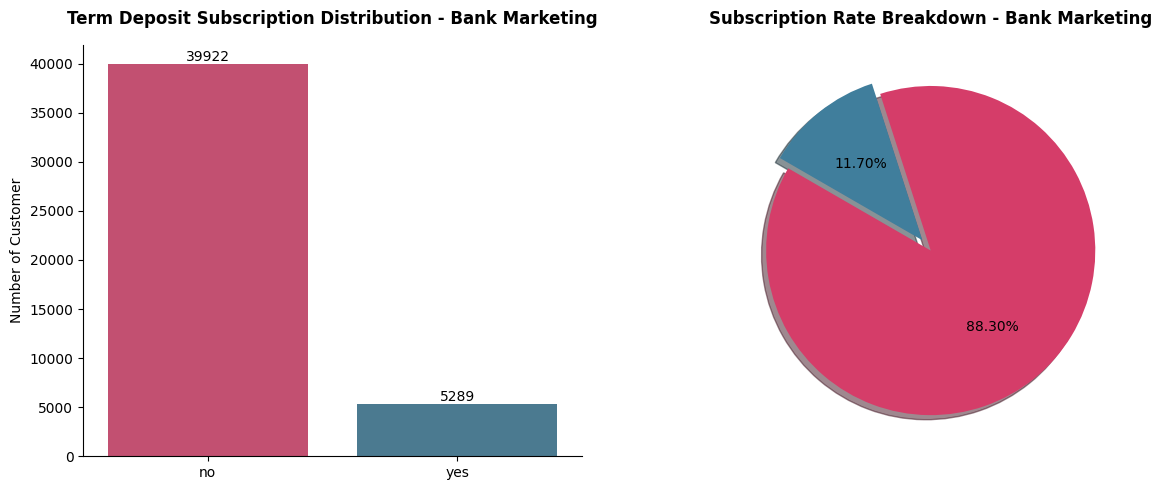

In [11]:
subscription_distribution  = df[config["data"]["target_feature"]].value_counts()
fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=(12, 5))
n_color = ColorUtils.color(n_colors=df[config["data"]["target_feature"]].nunique())
# ax[0]
sns.countplot(data=df, x = config["data"]["target_feature"], palette=n_color, 
              ax=ax[0])
ax[0].set_title("Term Deposit Subscription Distribution - Bank Marketing", weight="bold", fontsize=12, pad=15)
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%d", label_type="edge", fontsize=10)
ax[0].set_ylabel("Number of Customer")
ax[0].set_xlabel("")
sns.despine(ax=ax[0], top=True, right=True, left=False, bottom=False)

# ax[1]
ax[1].pie(
    subscription_distribution,
    colors = n_color,
    autopct = "%1.2f%%",
    startangle = 150,
    explode = (0, 0.08),
    shadow= True
)
ax[1].set_title("Subscription Rate Breakdown - Bank Marketing",  weight="bold", fontsize=12, pad=15)

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Insight
</div>

| Dataset      | No (0)  | Yes (1) | Yes Rate  |
| ------------ | ------- | ------- | --------- |
| **Original** | 39,922  | 5,289   | **11.7%** |

* **Majority class**: `'No'` (customers who did **not** subscribe to the term deposit)
* **Minority class**: `'Yes'` (subscribed)
* Both datasets show a **highly imbalanced target variable**, with only **\~12% positive class** (Yes).

</div>

## Numerical Feature Distributions

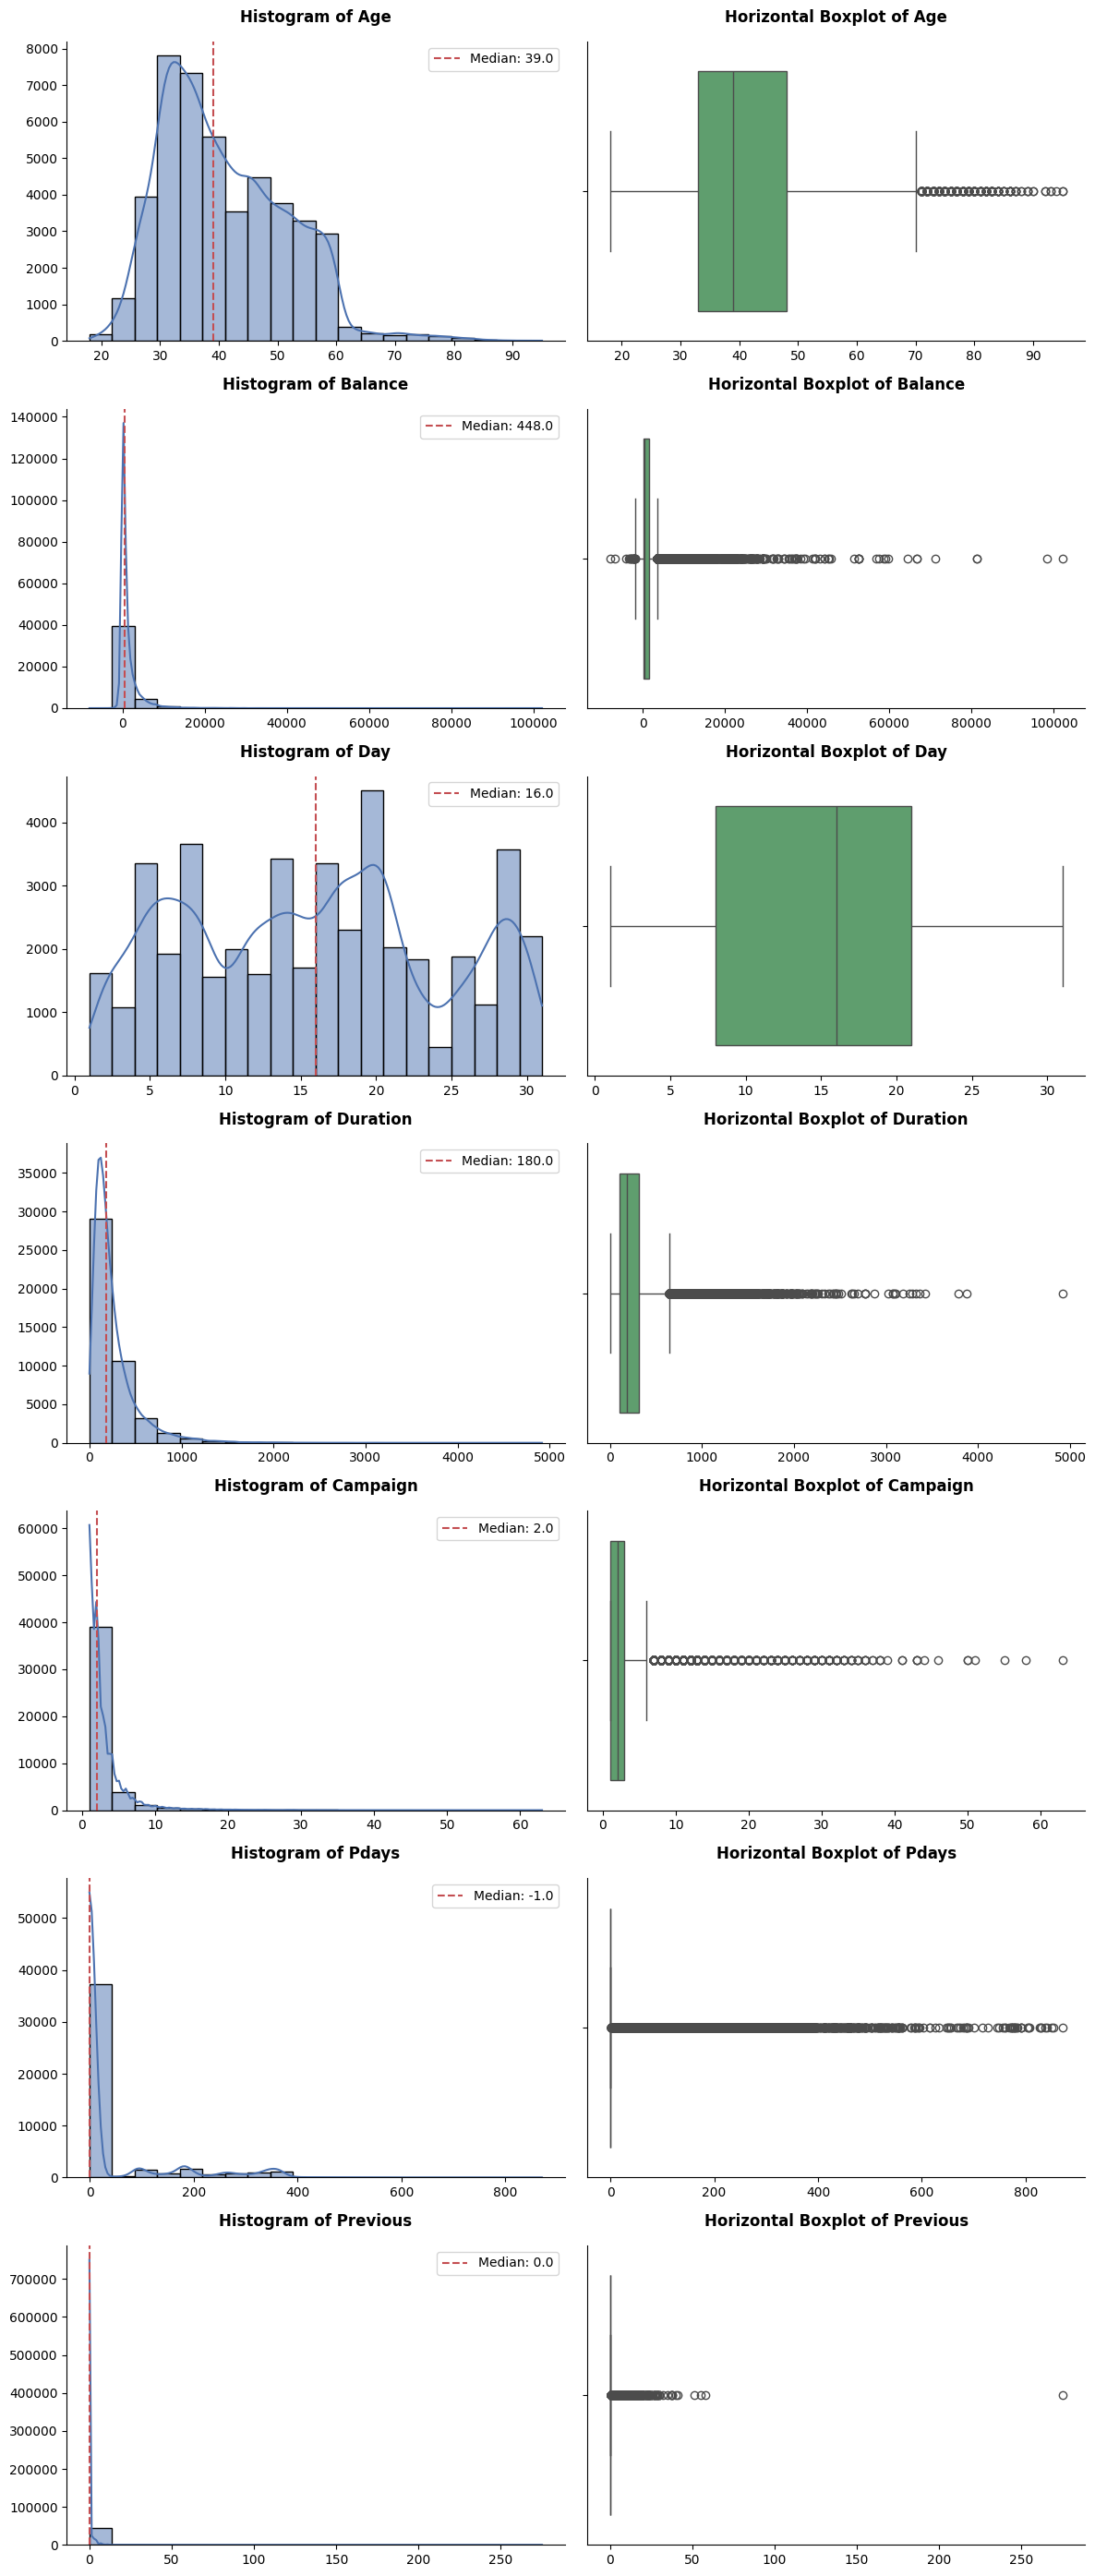

In [12]:
def plot_numerical_features(df=df, numerical_features = num_features):
    """
    Plot distribution of numerical features using Histogram and Boxplot.
    """

    # Create subplot grid
    fig, ax = plt.subplots(len(numerical_features), 2, figsize=(12, len(numerical_features)*4))
    # Ensure ax is always 2D (important if only 1 feature)
    ax = np.atleast_2d(ax)

    for i, feature in enumerate(numerical_features):
        # Histogram + KDE
        sns.histplot(data=df[feature], color="#4C72B0", bins = 20, kde=True, ax=ax[i, 0])
        ax[i, 0].set_title(f"Histogram of {feature.title()}", weight="bold", fontsize=12, pad=15)
        ax[i, 0].set_xlabel("")
        ax[i, 0].set_ylabel("")

        # Draw vertical line for median
        ax[i, 0].axvline(df[feature].median(), color="#C44E52", linestyle="--", label=f"Median: {df[feature].median()}")
        ax[i, 0].legend(loc="upper right")
        sns.despine(ax=ax[i, 0], top=True, right=True, left=False, bottom=False)

        # Horizontal Boxplot
        sns.boxplot(data=df[feature], color="#55A868", orient="h", ax=ax[i, 1])
        ax[i, 1].set_title(f"Horizontal Boxplot of {feature.title()}", weight="bold", fontsize=12, pad=15)
        ax[i, 1].set_xlabel("")
        sns.despine(ax=ax[i, 1], top=True, right=True, left=False, bottom=False)

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

plot_numerical_features()

In [13]:
skew_feature = DataValidator.check_skewness(data=df, dataset_name="Bank Marketing", 
                                            numerical_features=num_features, logger=logger)
logger.info("-" * 80)
logger.info("Checking skewness successfully completed the dataset.")

2026-03-09 14:11:15 | INFO     | Skewness analysis for Bank Marketing
2026-03-09 14:11:15 | INFO     | Total numerical features checked: 7
2026-03-09 14:11:15 | DEBUG    | ----------------------------------------------------------------------
2026-03-09 14:11:15 | DEBUG    | Feature                        | Skewness  | Remark
2026-03-09 14:11:15 | DEBUG    | ----------------------------------------------------------------------
2026-03-09 14:11:15 | DEBUG    | previous                       |  +41.8465 | Highly skewed
2026-03-09 14:11:15 | DEBUG    | balance                        |   +8.3603 | Highly skewed
2026-03-09 14:11:15 | DEBUG    | campaign                       |   +4.8987 | Highly skewed
2026-03-09 14:11:15 | DEBUG    | duration                       |   +3.1443 | Highly skewed
2026-03-09 14:11:15 | DEBUG    | pdays                          |   +2.6157 | Highly skewed
2026-03-09 14:11:15 | DEBUG    | age                            |   +0.6848 | Moderately skewed
2026-03-09 1

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Insight
</div>

* Most numerical features in the dataset are **right-skewed**, meaning values are concentrated at the lower range with **long tails and many outliers**.
* **5 out of 7 features** (`previous`, `balance`, `campaign`, `duration`, `pdays`) show **high skewness**, indicating non-normal distributions.
* `age` is **moderately skewed**, while `day` is **approximately symmetric**.
* Marketing interaction variables (`previous`, `campaign`, `pdays`) suggest that **most customers had little or no prior contact** with previous campaigns.
* **Data transformations** such as **log or Yeo-Johnson** and **outlier handling** are recommended before model training.
</div>

## Correlation Analysis of Numerical Features

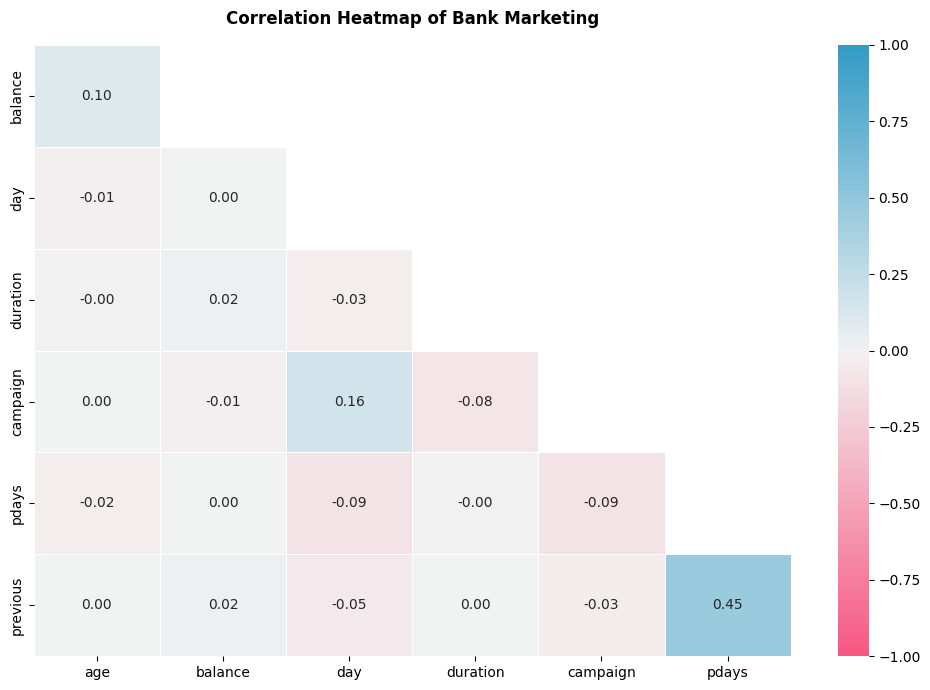

In [14]:
corr_matrix = df[num_features].corr(numeric_only=True)
# one_like can build a matrix of boolean(True, False) with the same shape as our data
ones_corr = np.ones_like(corr_matrix, dtype=bool)
mask = np.triu(ones_corr)
adjusted_mask = mask[1:, :-1]
adjusted_cereal_corr = corr_matrix.iloc[1:, :-1]

fig, ax = plt.subplots(figsize = (10, 7))
# That method uses HUSL colors, so you need hue, saturation, and lightness. 
# I used hsluv.org to select the colors of this chart.
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

sns.heatmap(data=adjusted_cereal_corr, mask=adjusted_mask,
            annot=True, fmt=".2f", cmap=cmap,
            vmin=-1, vmax=1, linecolor="white", linewidths=0.5)

title = "Correlation Heatmap of Bank Marketing"
ax.set_title(title, loc="center", fontsize=12, weight="bold", pad=15)
plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Correlation Insights
</div>

* Most numerical variables show **very weak correlations**, indicating largely independent customer behavior signals.
* A **moderate correlation between `pdays` and `previous` (≈0.45–0.55)** suggests recently contacted customers tend to have more past interactions.
* Overall, the dataset presents **low multicollinearity risk**, which is beneficial for interpretable models.
</div>

## Categorical Feature Distributions

In [15]:
def plot_categorical_distribution_across_datasets(df: pd.DataFrame, feature: str) -> None:
    """
    Display distribution summary of a categorical feature with styled table.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.
    feature : str
        Categorical column to analyze.
    """

    # --- Summarize categorical feature ---
    summary = (
        df[feature]
        .value_counts()
        .rename_axis("Category")
        .reset_index(name="Data_Count")
    )

    # Calculate percentage distribution
    summary["Data_%"] = round(summary["Data_Count"] / summary["Data_Count"].sum() * 100, 2)

    # Ensure Category column is string
    summary["Category"] = summary["Category"].astype(str)

    # Fill NA if any
    summary[["Data_Count", "Data_%"]] = summary[["Data_Count", "Data_%"]].fillna(0)

    # ---- Styling with color gradient ----
    styled_table = (
        summary.style
        .background_gradient(cmap="Blues", subset=["Data_Count"])
        .background_gradient(cmap="Blues", subset=["Data_%"])
        .format({
            "Data_Count": "{:,}",
            "Data_%": "{:.2f}%"
        })
        .set_caption(f"Categorical Feature Distribution: {feature.title()}")
        .set_table_styles([
            {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]},
            {"selector": "th", "props": [("text-align", "center")]},
            {"selector": "td", "props": [("text-align", "center")]}
        ])
    )

    display(styled_table)
    print("*" * 80)

# ----- Run for all categorical features -----
for feature in cat_features:
    plot_categorical_distribution_across_datasets(df=df, feature=feature)

,Category,Data_Count,Data_%
0,blue-collar,"9,732",21.53%
1,management,"9,458",20.92%
2,technician,"7,597",16.80%
3,admin.,"5,171",11.44%
4,services,"4,154",9.19%
5,retired,"2,264",5.01%
6,self-employed,"1,579",3.49%
7,entrepreneur,"1,487",3.29%
8,unemployed,"1,303",2.88%
9,housemaid,"1,240",2.74%


********************************************************************************


,Category,Data_Count,Data_%
0,married,"27,214",60.19%
1,single,"12,790",28.29%
2,divorced,"5,207",11.52%


********************************************************************************


,Category,Data_Count,Data_%
0,secondary,"23,202",51.32%
1,tertiary,"13,301",29.42%
2,primary,"6,851",15.15%
3,unknown,"1,857",4.11%


...

********************************************************************************


,Category,Data_Count,Data_%
0,may,"13,766",30.45%
1,jul,"6,895",15.25%
2,aug,"6,247",13.82%
3,jun,"5,341",11.81%
4,nov,"3,970",8.78%
5,apr,"2,932",6.49%
6,feb,"2,649",5.86%
7,jan,"1,403",3.10%
8,oct,738,1.63%
9,sep,579,1.28%


********************************************************************************


,Category,Data_Count,Data_%
0,unknown,"36,959",81.75%
1,failure,"4,901",10.84%
2,other,"1,840",4.07%
3,success,"1,511",3.34%


********************************************************************************


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Categorical Feature Distributions
</div>

* The dataset is dominated by **working-age customers**, with the largest job groups being **blue-collar (21.5%)**, **management (20.9%)**, and **technician (16.8%)**.
* Most customers are **married (60%)** and have **secondary or tertiary education (~80%)**, indicating a relatively stable socio-economic profile.
* The majority **do not have credit default (98%)**, while **housing loans are common (55%)** but **personal loans are less frequent (16%)**.
* **Cellular contact (65%)** is the primary communication channel, suggesting a strong reliance on mobile outreach.
* Campaigns are heavily concentrated in **May (~30%)**, and most customers have **no previous campaign outcome recorded (82% “unknown”)**, indicating limited historical marketing interactions.

</div>

## Bivariate Analysis

,y,Count,Mean,Median,Std
0,yes,5289,41.670070,38.000000,13.497781
1,no,39922,40.838986,39.000000,10.172662


2026-03-09 14:11:15 | INFO     | Checking normality of feature 'age' by groups of 'y'...
2026-03-09 14:11:15 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-03-09 14:11:15 | DEBUG    | Number of groups detected: 2
2026-03-09 14:11:15 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-03-09 14:11:15 | DEBUG    | [y=no] skew=0.5920, kurtosis=0.0520 → Moderately skewed, Normal tails
2026-03-09 14:11:15 | DEBUG    | [y=yes] skew=0.8668, kurtosis=0.2853 → Moderately skewed, Normal tails
2026-03-09 14:11:15 | INFO     | Generating Q–Q plots for visual assessment...


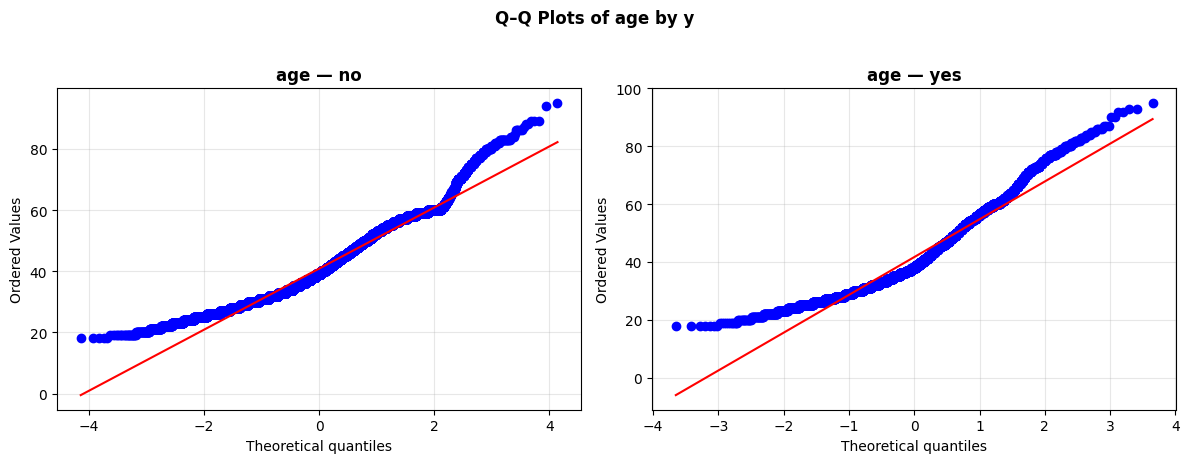

,Feature,Group,Skewness,Kurtosis,Remark
0,age,no,0.5920,0.0520,"Moderately skewed, Normal tails"
1,age,yes,0.8668,0.2853,"Moderately skewed, Normal tails"


2026-03-09 14:11:15 | WARNING  | Normality assumption violated in at least one group.
2026-03-09 14:11:15 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-03-09 14:11:15 | INFO     | Running Mann–Whitney U Test: 'age' by 'y'...
2026-03-09 14:11:15 | DEBUG    | Number of groups detected: 2
2026-03-09 14:11:15 | INFO     | U statistic: 107232348.5
2026-03-09 14:11:15 | INFO     | p-value    : 0.062818
2026-03-09 14:11:15 | WARNING  | Result: p-value > 0.05 → Fail to reject H0
2026-03-09 14:11:15 | WARNING  | Conclusion: No statistically significant difference detected.


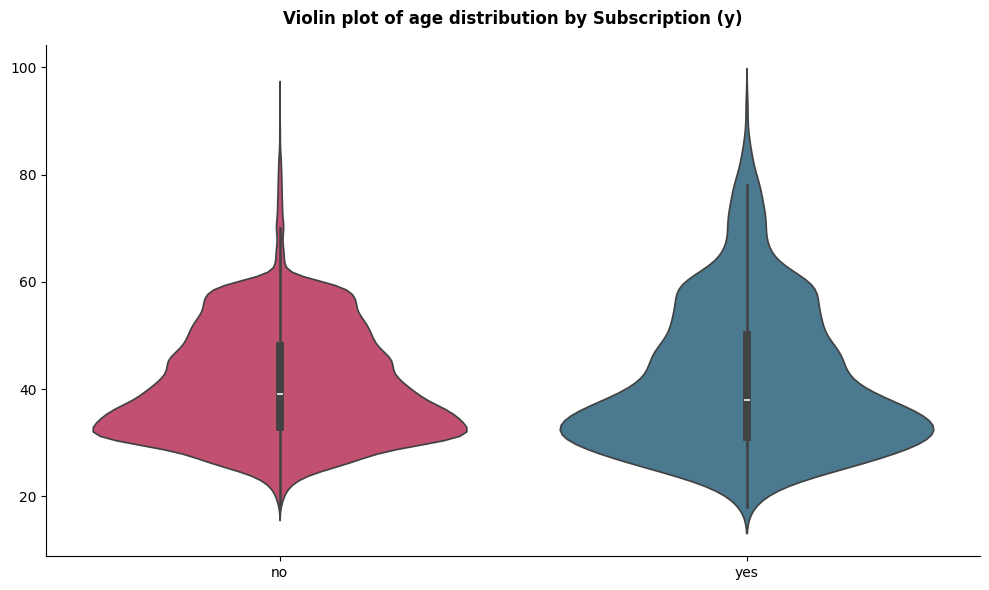

,y,Count,Mean,Median,Std
0,yes,5289,1804.267915,733.000000,3501.104777
1,no,39922,1303.714969,417.000000,2974.195473


2026-03-09 14:11:16 | INFO     | Checking normality of feature 'balance' by groups of 'y'...
2026-03-09 14:11:16 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-03-09 14:11:16 | DEBUG    | Number of groups detected: 2
2026-03-09 14:11:16 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-03-09 14:11:16 | DEBUG    | [y=no] skew=8.3101, kurtosis=140.5112 → Highly skewed, Heavy/light tails
2026-03-09 14:11:16 | DEBUG    | [y=yes] skew=8.4443, kurtosis=133.9180 → Highly skewed, Heavy/light tails
2026-03-09 14:11:16 | INFO     | Generating Q–Q plots for visual assessment...


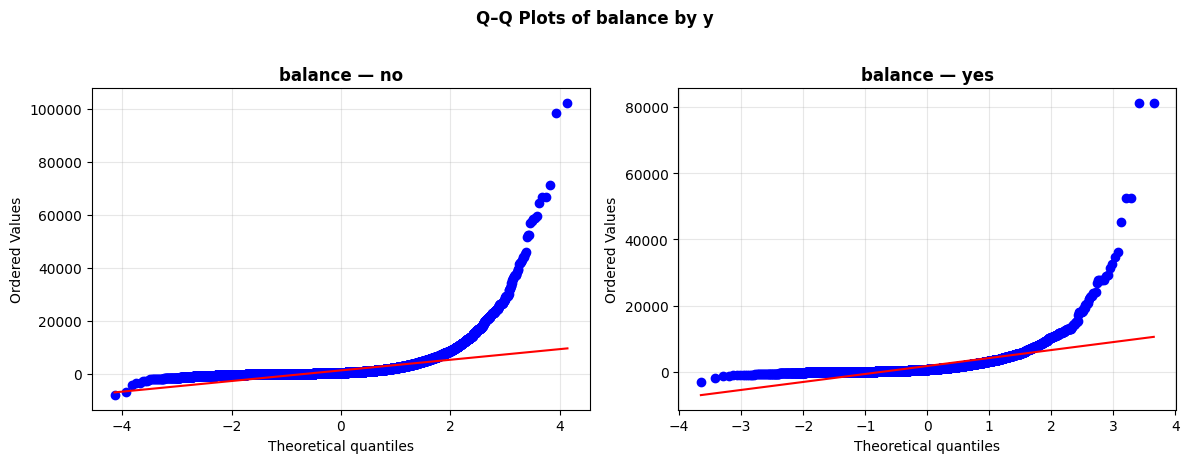

,Feature,Group,Skewness,Kurtosis,Remark
0,balance,no,8.3101,140.5112,"Highly skewed, Heavy/light tails"
1,balance,yes,8.4443,133.9180,"Highly skewed, Heavy/light tails"


2026-03-09 14:11:16 | WARNING  | Normality assumption violated in at least one group.
2026-03-09 14:11:16 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-03-09 14:11:16 | INFO     | Running Mann–Whitney U Test: 'balance' by 'y'...
2026-03-09 14:11:16 | DEBUG    | Number of groups detected: 2
2026-03-09 14:11:16 | INFO     | U statistic: 86557474.5
2026-03-09 14:11:16 | INFO     | p-value    : 0.000000
2026-03-09 14:11:16 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-03-09 14:11:16 | INFO     | Conclusion: Significant difference between the two groups.
2026-03-09 14:11:16 | INFO     | Effect size interpretation: Small


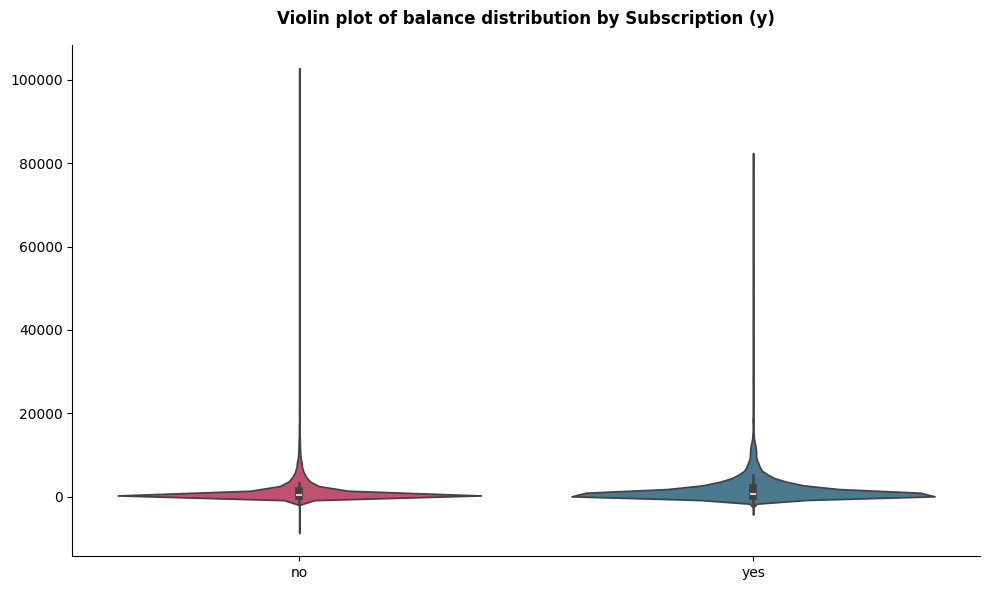

,y,Count,Mean,Median,Std
0,no,39922,15.892290,16.000000,8.294728
1,yes,5289,15.158253,15.000000,8.501875


2026-03-09 14:11:16 | INFO     | Checking normality of feature 'day' by groups of 'y'...
2026-03-09 14:11:16 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-03-09 14:11:16 | DEBUG    | Number of groups detected: 2
2026-03-09 14:11:16 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-03-09 14:11:16 | DEBUG    | [y=no] skew=0.0839, kurtosis=-1.0596 → Approximately symmetric, Normal tails
2026-03-09 14:11:16 | DEBUG    | [y=yes] skew=0.1695, kurtosis=-1.0528 → Approximately symmetric, Normal tails
2026-03-09 14:11:16 | INFO     | Generating Q–Q plots for visual assessment...


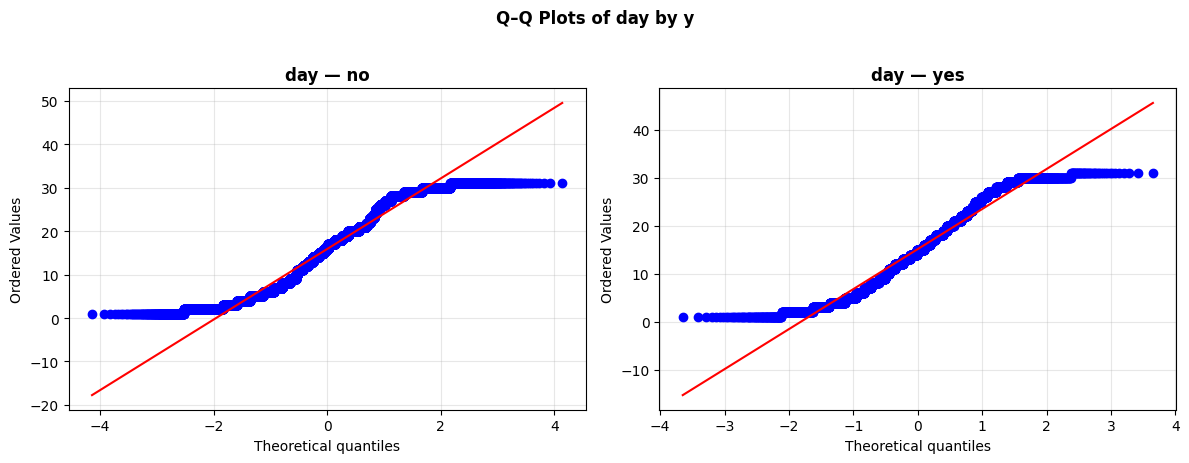

,Feature,Group,Skewness,Kurtosis,Remark
0,day,no,0.0839,-1.0596,"Approximately symmetric, Normal tails"
1,day,yes,0.1695,-1.0528,"Approximately symmetric, Normal tails"


2026-03-09 14:11:17 | INFO     | All groups approximately follow a normal distribution.
2026-03-09 14:11:17 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-03-09 14:11:17 | DEBUG    | Number of groups detected: 2


,Metric,Value
0,Levene’s Statistic,5.6197
1,p-value,0.017764
2,Max/Min Variance Ratio,1.05


2026-03-09 14:11:17 | INFO     | Interpretation:
2026-03-09 14:11:17 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-03-09 14:11:17 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-03-09 14:11:17 | INFO     | Running Independent Two-Sample T-Test: 'day' ~ 'y'
2026-03-09 14:11:17 | DEBUG    | Number of groups detected: 2
2026-03-09 14:11:17 | DEBUG    | Test Type: Welch’s T-Test (unequal variances)
2026-03-09 14:11:17 | INFO     | Comparing groups: 'no' vs 'yes'
2026-03-09 14:11:17 | INFO     | p-value: 0.000000
2026-03-09 14:11:17 | INFO     | Cohen's d: 0.087
2026-03-09 14:11:17 | DEBUG    | t-statistic: 5.917
2026-03-09 14:11:17 | DEBUG    | Group means → no: 15.892, yes: 15.158
2026-03-09 14:11:17 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-03-09 14:11:17 | INFO     | Conclusion: Significant difference between the two groups.
2026-03-09 14:11:17 | INFO   

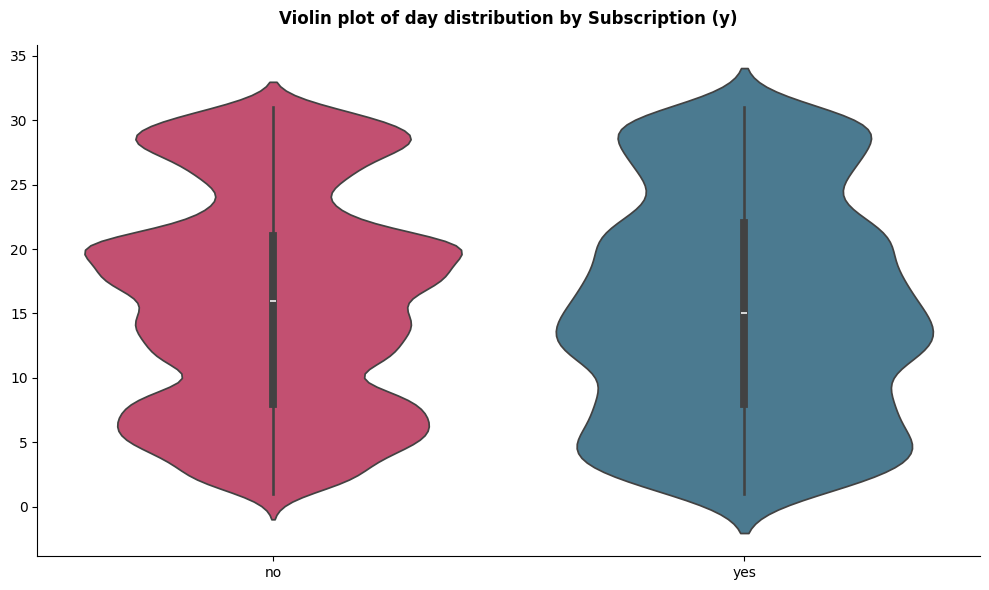

,y,Count,Mean,Median,Std
0,yes,5289,537.294574,426.000000,392.525262
1,no,39922,221.182806,164.000000,207.383237


2026-03-09 14:11:17 | INFO     | Checking normality of feature 'duration' by groups of 'y'...
2026-03-09 14:11:17 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-03-09 14:11:17 | DEBUG    | Number of groups detected: 2
2026-03-09 14:11:17 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-03-09 14:11:17 | DEBUG    | [y=no] skew=3.5892, kurtosis=28.9521 → Highly skewed, Heavy/light tails
2026-03-09 14:11:17 | DEBUG    | [y=yes] skew=1.7044, kurtosis=4.9676 → Highly skewed, Heavy/light tails
2026-03-09 14:11:17 | INFO     | Generating Q–Q plots for visual assessment...


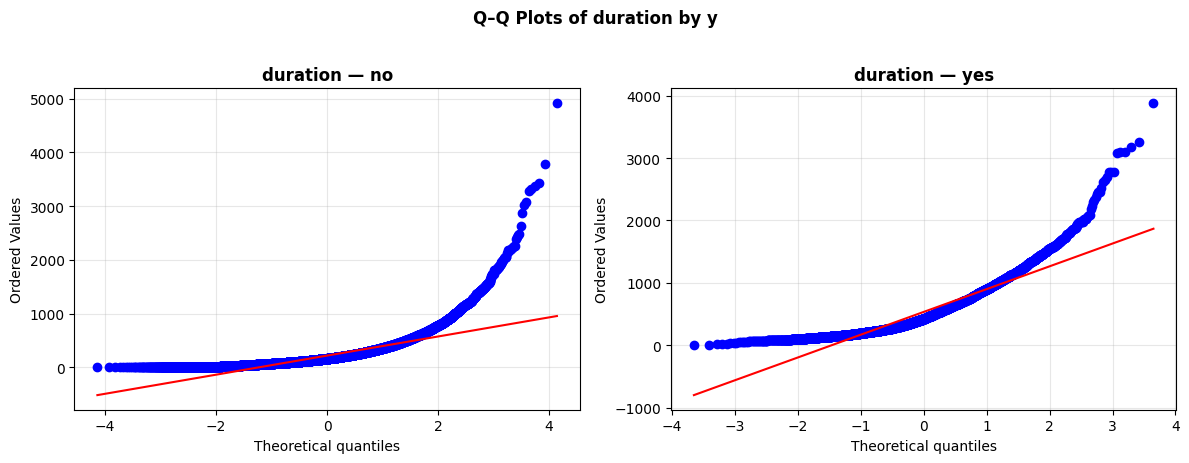

,Feature,Group,Skewness,Kurtosis,Remark
0,duration,no,3.5892,28.9521,"Highly skewed, Heavy/light tails"
1,duration,yes,1.7044,4.9676,"Highly skewed, Heavy/light tails"


2026-03-09 14:11:17 | WARNING  | Normality assumption violated in at least one group.
2026-03-09 14:11:17 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-03-09 14:11:17 | INFO     | Running Mann–Whitney U Test: 'duration' by 'y'...
2026-03-09 14:11:17 | DEBUG    | Number of groups detected: 2
2026-03-09 14:11:17 | INFO     | U statistic: 40625701.0
2026-03-09 14:11:17 | INFO     | p-value    : 0.000000
2026-03-09 14:11:17 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-03-09 14:11:17 | INFO     | Conclusion: Significant difference between the two groups.
2026-03-09 14:11:17 | INFO     | Effect size interpretation: Medium


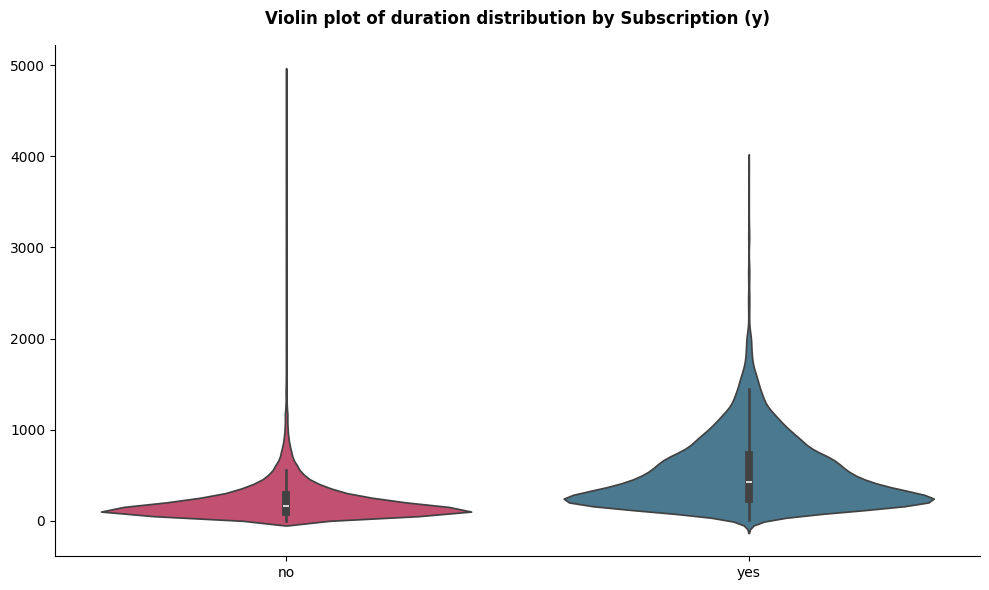

,y,Count,Mean,Median,Std
0,no,39922,2.846350,2.000000,3.212767
1,yes,5289,2.141047,2.000000,1.921826


2026-03-09 14:11:18 | INFO     | Checking normality of feature 'campaign' by groups of 'y'...
2026-03-09 14:11:18 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-03-09 14:11:18 | DEBUG    | Number of groups detected: 2
2026-03-09 14:11:18 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-03-09 14:11:18 | DEBUG    | [y=no] skew=4.8015, kurtosis=37.3068 → Highly skewed, Heavy/light tails
2026-03-09 14:11:18 | DEBUG    | [y=yes] skew=4.3756, kurtosis=35.1061 → Highly skewed, Heavy/light tails
2026-03-09 14:11:18 | INFO     | Generating Q–Q plots for visual assessment...


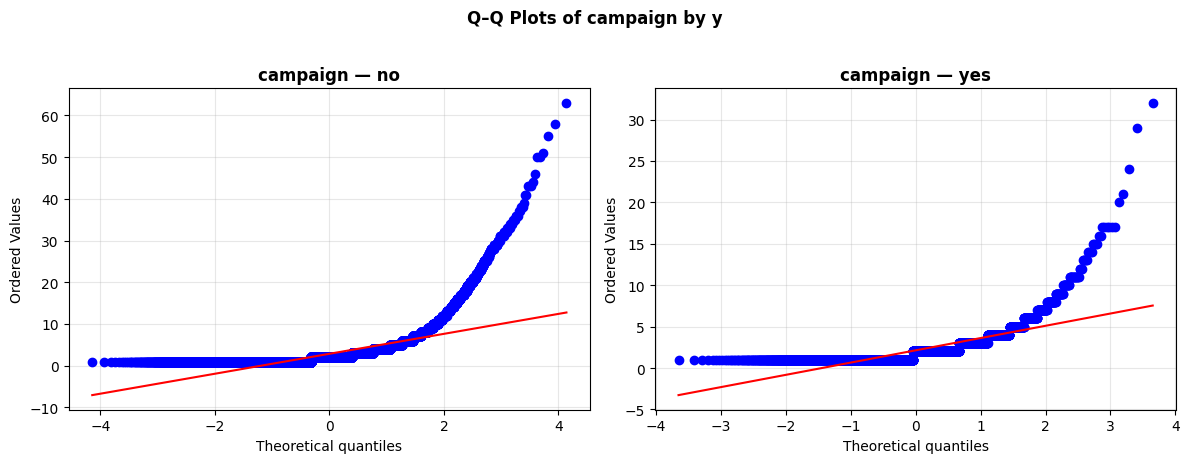

,Feature,Group,Skewness,Kurtosis,Remark
0,campaign,no,4.8015,37.3068,"Highly skewed, Heavy/light tails"
1,campaign,yes,4.3756,35.1061,"Highly skewed, Heavy/light tails"


2026-03-09 14:11:18 | WARNING  | Normality assumption violated in at least one group.
2026-03-09 14:11:18 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-03-09 14:11:18 | INFO     | Running Mann–Whitney U Test: 'campaign' by 'y'...
2026-03-09 14:11:18 | DEBUG    | Number of groups detected: 2
2026-03-09 14:11:18 | INFO     | U statistic: 120846914.5
2026-03-09 14:11:18 | INFO     | p-value    : 0.000000
2026-03-09 14:11:18 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-03-09 14:11:18 | INFO     | Conclusion: Significant difference between the two groups.
2026-03-09 14:11:18 | INFO     | Effect size interpretation: Negligible


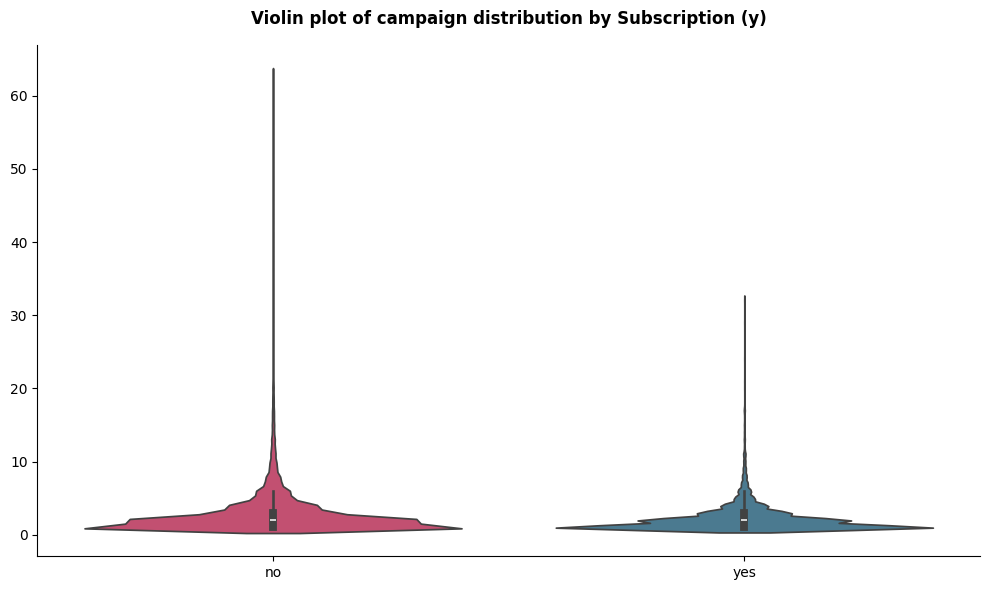

,y,Count,Mean,Median,Std
0,yes,5289,68.702968,-1.000000,118.822266
1,no,39922,36.421372,-1.000000,96.757135


2026-03-09 14:11:18 | INFO     | Checking normality of feature 'pdays' by groups of 'y'...
2026-03-09 14:11:18 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-03-09 14:11:18 | DEBUG    | Number of groups detected: 2
2026-03-09 14:11:18 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-03-09 14:11:18 | DEBUG    | [y=no] skew=2.6956, kurtosis=7.0310 → Highly skewed, Heavy/light tails
2026-03-09 14:11:18 | DEBUG    | [y=yes] skew=2.1375, kurtosis=5.4999 → Highly skewed, Heavy/light tails
2026-03-09 14:11:18 | INFO     | Generating Q–Q plots for visual assessment...


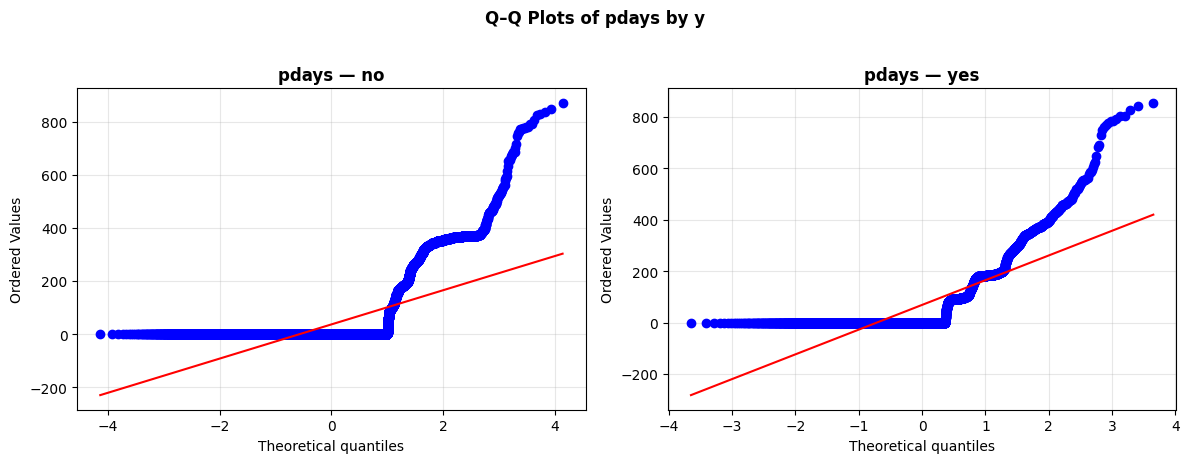

,Feature,Group,Skewness,Kurtosis,Remark
0,pdays,no,2.6956,7.0310,"Highly skewed, Heavy/light tails"
1,pdays,yes,2.1375,5.4999,"Highly skewed, Heavy/light tails"


2026-03-09 14:11:19 | WARNING  | Normality assumption violated in at least one group.
2026-03-09 14:11:19 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-03-09 14:11:19 | INFO     | Running Mann–Whitney U Test: 'pdays' by 'y'...
2026-03-09 14:11:19 | DEBUG    | Number of groups detected: 2
2026-03-09 14:11:19 | INFO     | U statistic: 85889711.5
2026-03-09 14:11:19 | INFO     | p-value    : 0.000000
2026-03-09 14:11:19 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-03-09 14:11:19 | INFO     | Conclusion: Significant difference between the two groups.
2026-03-09 14:11:19 | INFO     | Effect size interpretation: Small


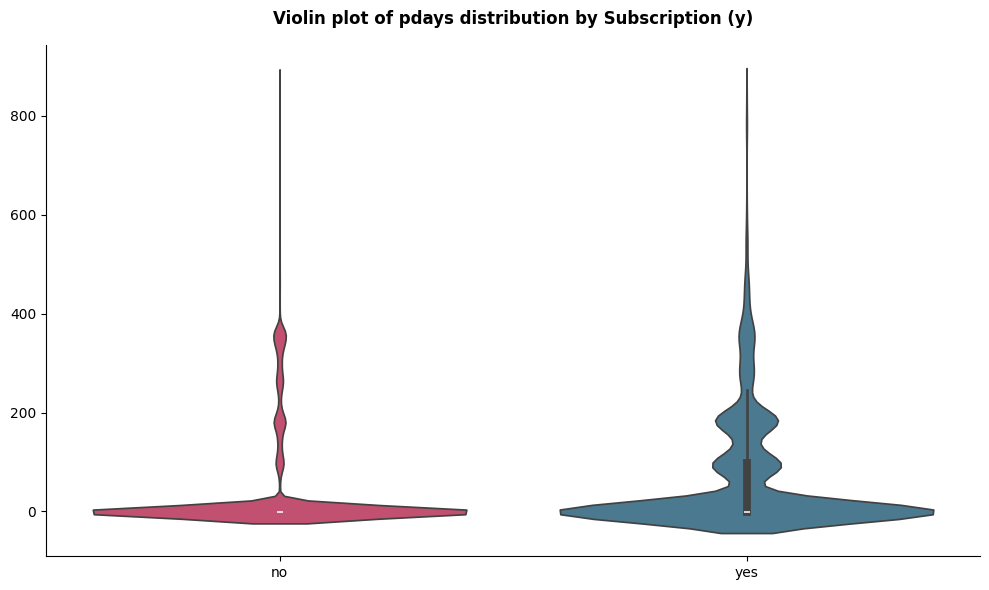

,y,Count,Mean,Median,Std
0,yes,5289,1.170354,0.000000,2.553272
1,no,39922,0.502154,0.000000,2.256771


2026-03-09 14:11:19 | INFO     | Checking normality of feature 'previous' by groups of 'y'...
2026-03-09 14:11:19 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-03-09 14:11:19 | DEBUG    | Number of groups detected: 2
2026-03-09 14:11:19 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-03-09 14:11:19 | DEBUG    | [y=no] skew=49.0910, kurtosis=5523.0048 → Highly skewed, Heavy/light tails
2026-03-09 14:11:19 | DEBUG    | [y=yes] skew=6.6097, kurtosis=98.0108 → Highly skewed, Heavy/light tails
2026-03-09 14:11:19 | INFO     | Generating Q–Q plots for visual assessment...


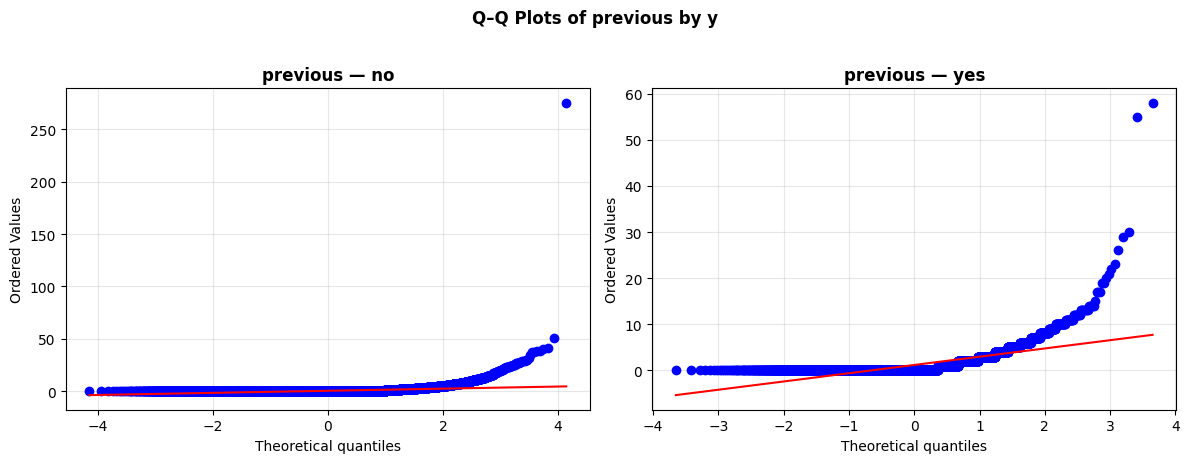

,Feature,Group,Skewness,Kurtosis,Remark
0,previous,no,49.0910,5523.0048,"Highly skewed, Heavy/light tails"
1,previous,yes,6.6097,98.0108,"Highly skewed, Heavy/light tails"


2026-03-09 14:11:19 | WARNING  | Normality assumption violated in at least one group.
2026-03-09 14:11:19 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-03-09 14:11:19 | INFO     | Running Mann–Whitney U Test: 'previous' by 'y'...
2026-03-09 14:11:19 | DEBUG    | Number of groups detected: 2
2026-03-09 14:11:19 | INFO     | U statistic: 83972625.0
2026-03-09 14:11:19 | INFO     | p-value    : 0.000000
2026-03-09 14:11:19 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-03-09 14:11:19 | INFO     | Conclusion: Significant difference between the two groups.
2026-03-09 14:11:19 | INFO     | Effect size interpretation: Small


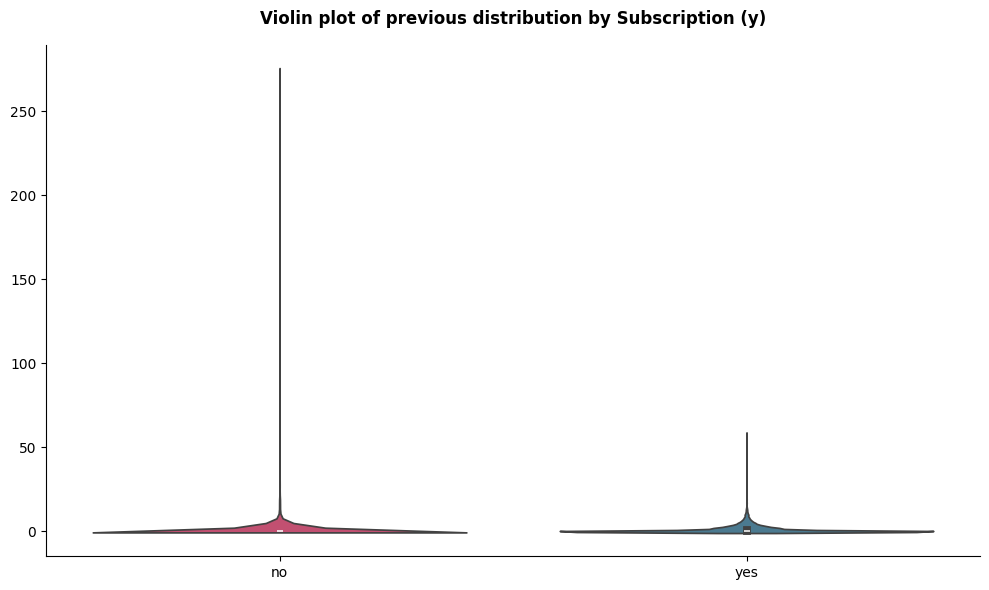

In [16]:
for feature in num_features:
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {feature.title()} by Subscription</b></h2>"))
    StatUtils.analyze_numeric_feature_by_target(feature=feature, df=df, target_feature=config["data"]["target_feature"], logger=logger)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Numerical Features vs Subscription – Key Insights
</div>

`Age`  
No significant difference in age distribution between subscribers and non-subscribers (**p > 0.05**), suggesting **age is not a strong driver of subscription**.

`Balance`  
Customers who **subscribed tend to have higher account balances**, suggesting a **possible link between financial capacity and subscription decisions**.

`Day`  
Subscribed customers are typically **contacted earlier in the month**, indicating that **earlier contact timing may improve subscription likelihood**.

`Duration`  
Call **duration is a strong indicator of subscription** — customers who subscribe generally **have longer call durations**.

`Campaign`  
Non-subscribers tend to receive **slightly more contact attempts**, suggesting that **repeated calls may occur when customers are less likely to subscribe**.

`Pdays`  
Customers who were **contacted more recently after a previous campaign** are **more likely to subscribe**, highlighting the importance of **timely follow-up**.

`Previous`  
Subscribed customers tend to have **slightly more prior contacts**, suggesting that **past interactions may positively influence subscription decisions**.

</div>

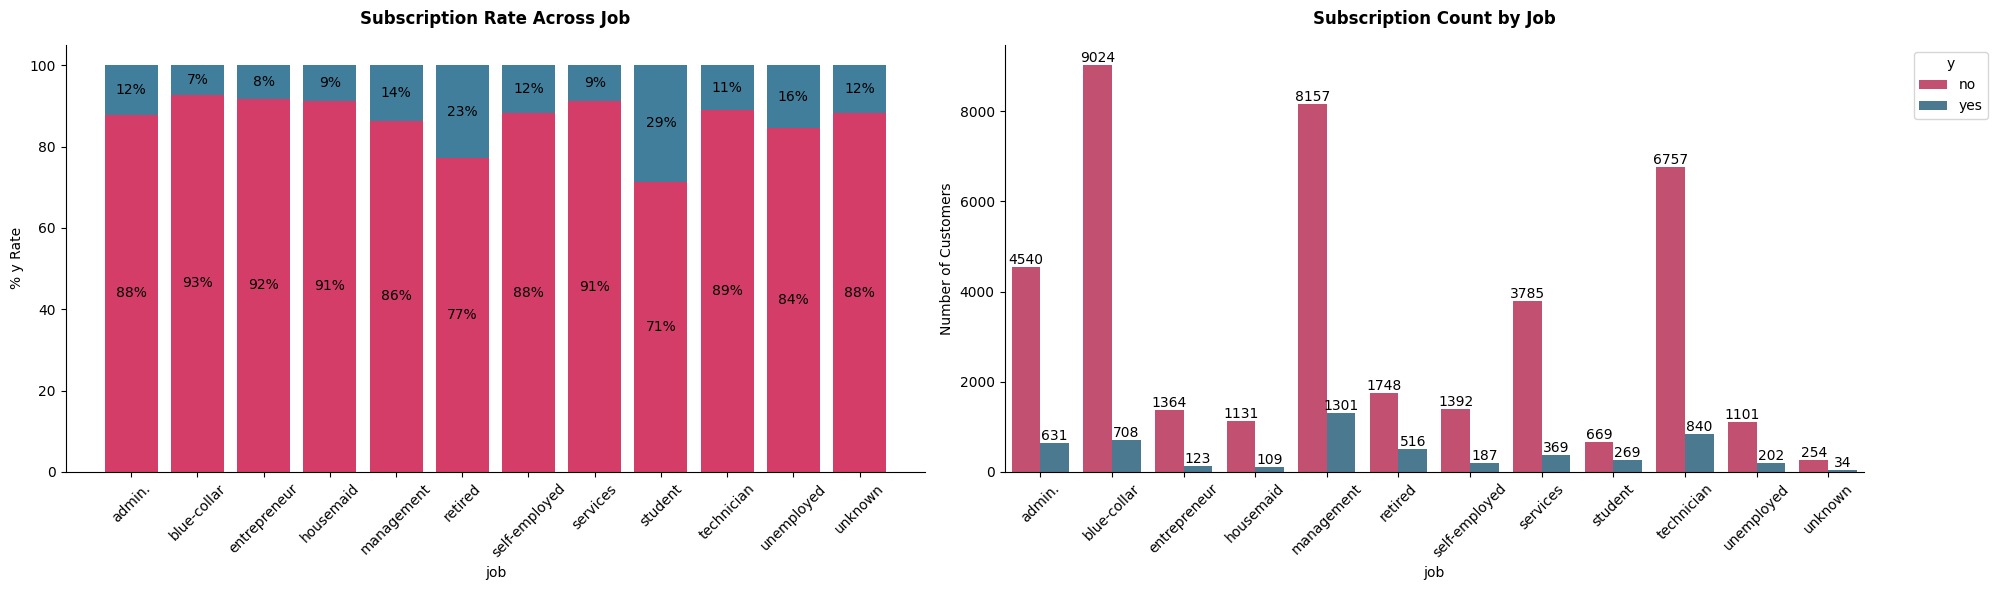

2026-03-09 14:11:20 | INFO     | Chi-Square Test of Independence: 'job' vs. 'y'...
2026-03-09 14:11:20 | INFO     | Chi-squared statistic: 836.105
2026-03-09 14:11:20 | INFO     | Degrees of freedom: 11
2026-03-09 14:11:20 | INFO     | p-value: 0.000000
2026-03-09 14:11:20 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-09 14:11:20 | INFO     | Variables 'job' and 'y' are statistically associated.
2026-03-09 14:11:20 | DEBUG    | Displaying standardized residuals heatmap.


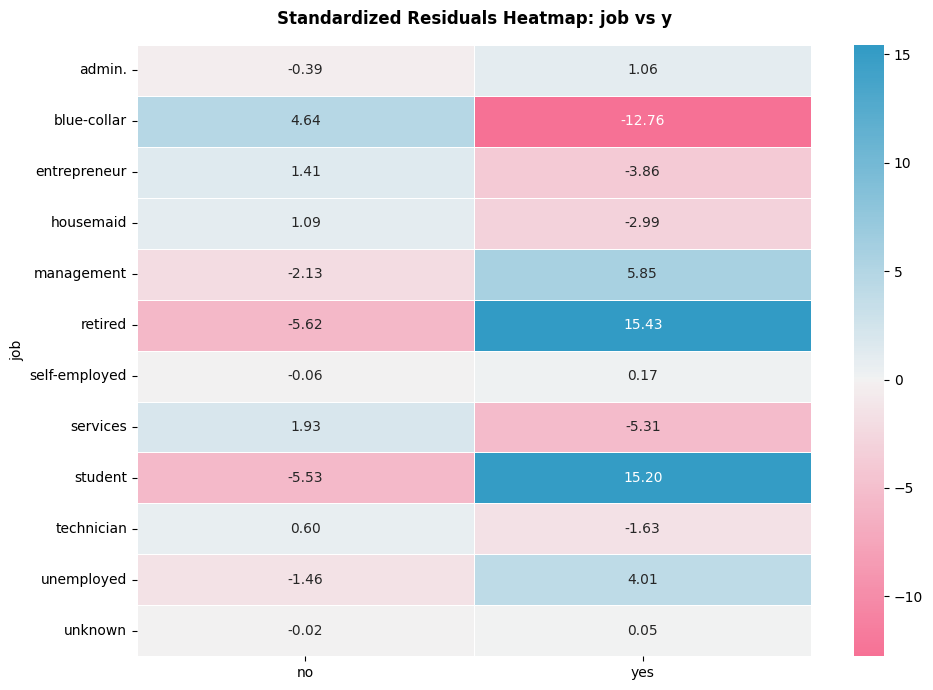

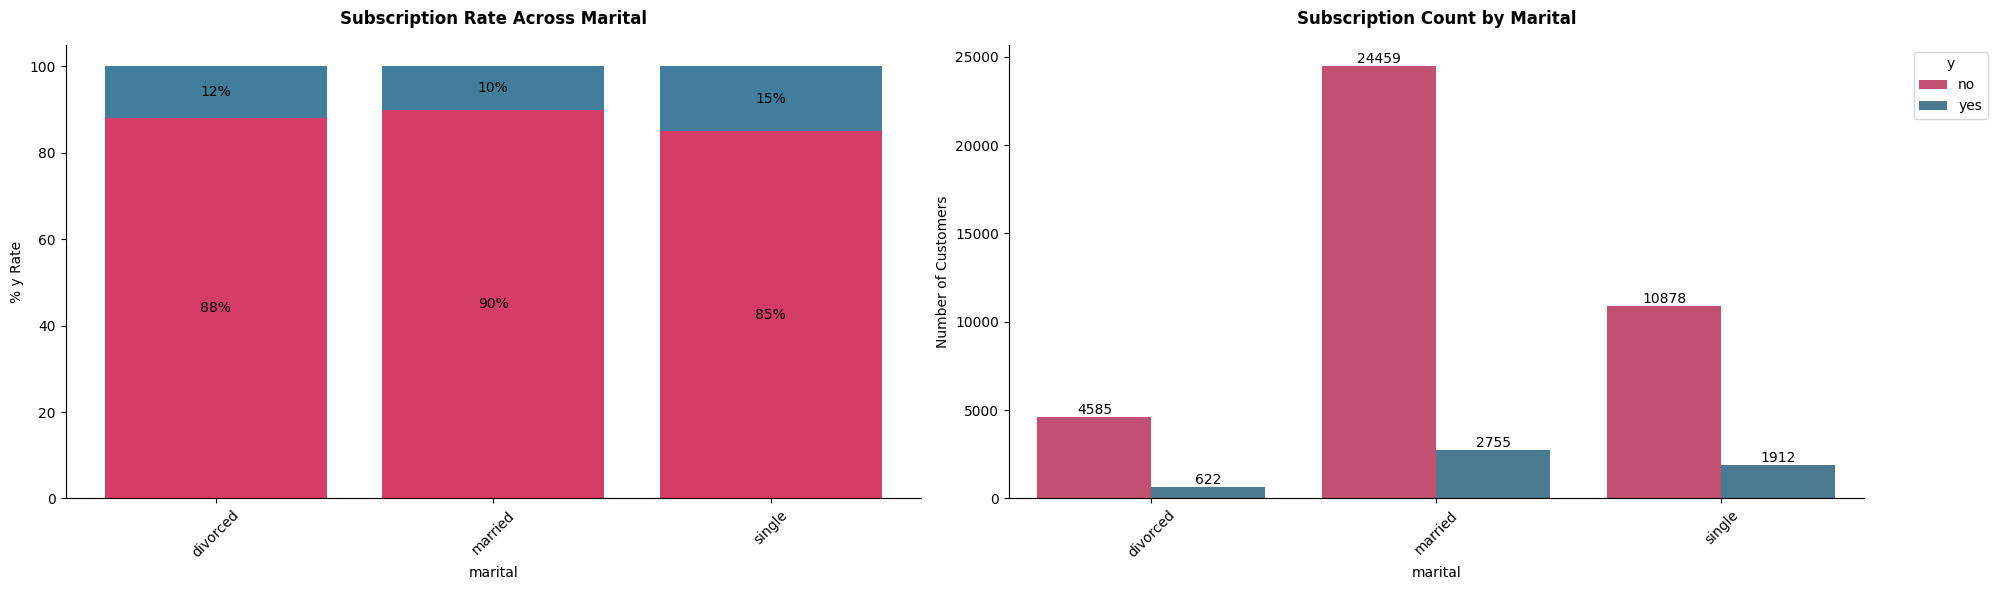

2026-03-09 14:11:20 | INFO     | Chi-Square Test of Independence: 'marital' vs. 'y'...
2026-03-09 14:11:20 | INFO     | Chi-squared statistic: 196.496
2026-03-09 14:11:20 | INFO     | Degrees of freedom: 2
2026-03-09 14:11:20 | INFO     | p-value: 0.000000
2026-03-09 14:11:20 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-09 14:11:20 | INFO     | Variables 'marital' and 'y' are statistically associated.
2026-03-09 14:11:20 | DEBUG    | Displaying standardized residuals heatmap.


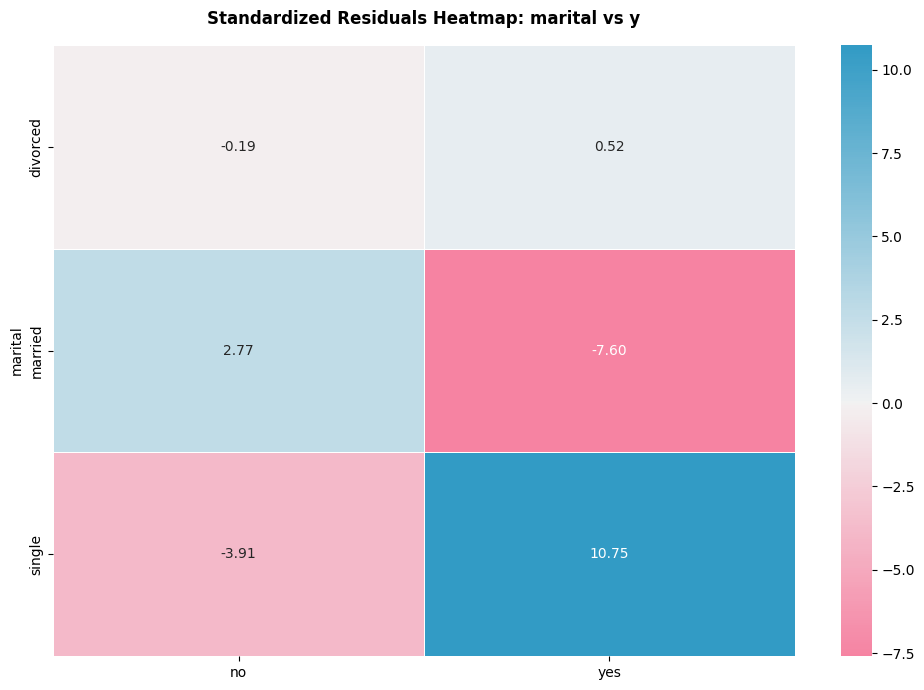

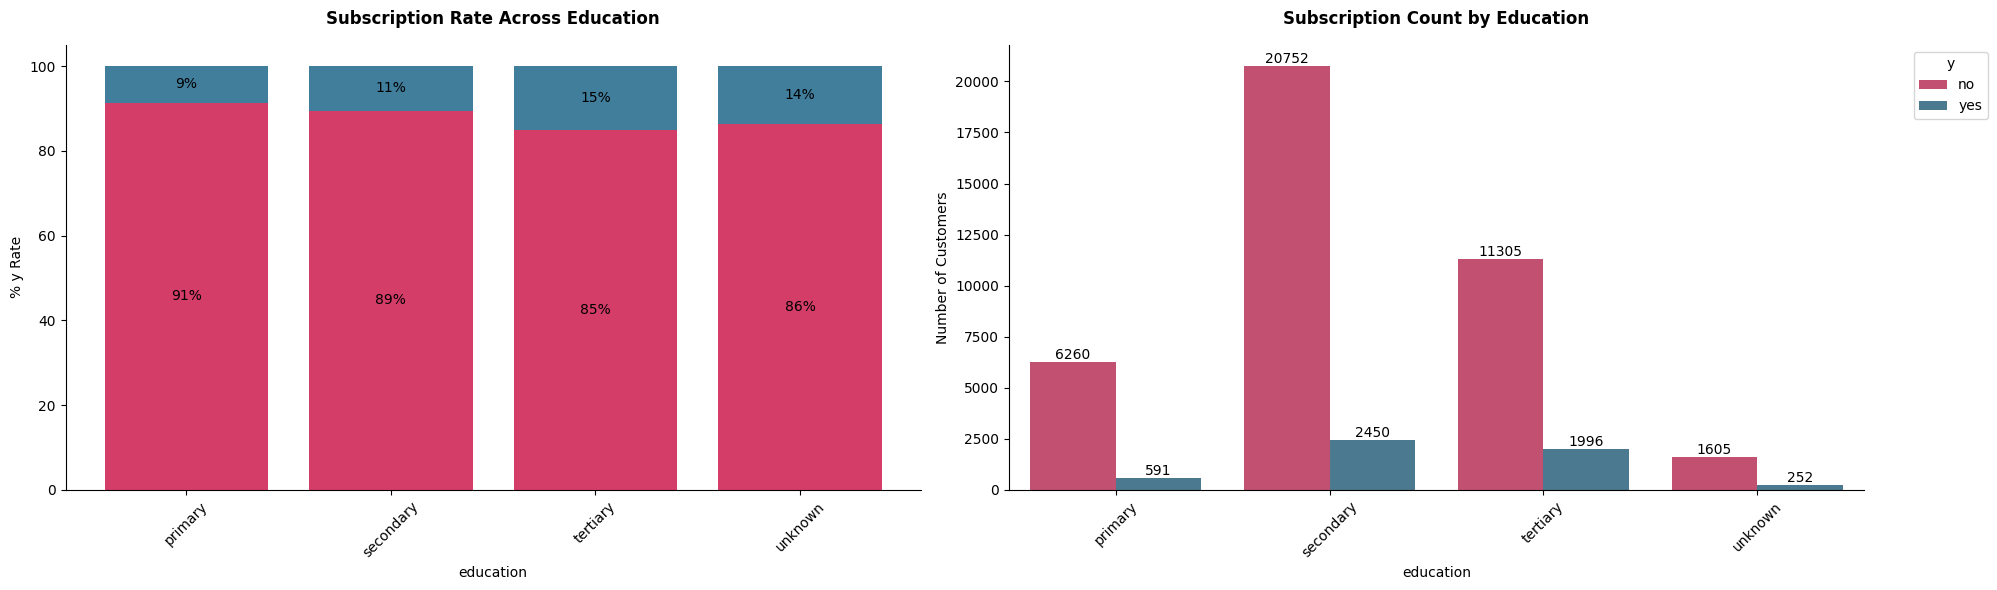

2026-03-09 14:11:21 | INFO     | Chi-Square Test of Independence: 'education' vs. 'y'...
2026-03-09 14:11:21 | INFO     | Chi-squared statistic: 238.924
2026-03-09 14:11:21 | INFO     | Degrees of freedom: 3
2026-03-09 14:11:21 | INFO     | p-value: 0.000000
2026-03-09 14:11:21 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-09 14:11:21 | INFO     | Variables 'education' and 'y' are statistically associated.
2026-03-09 14:11:21 | DEBUG    | Displaying standardized residuals heatmap.


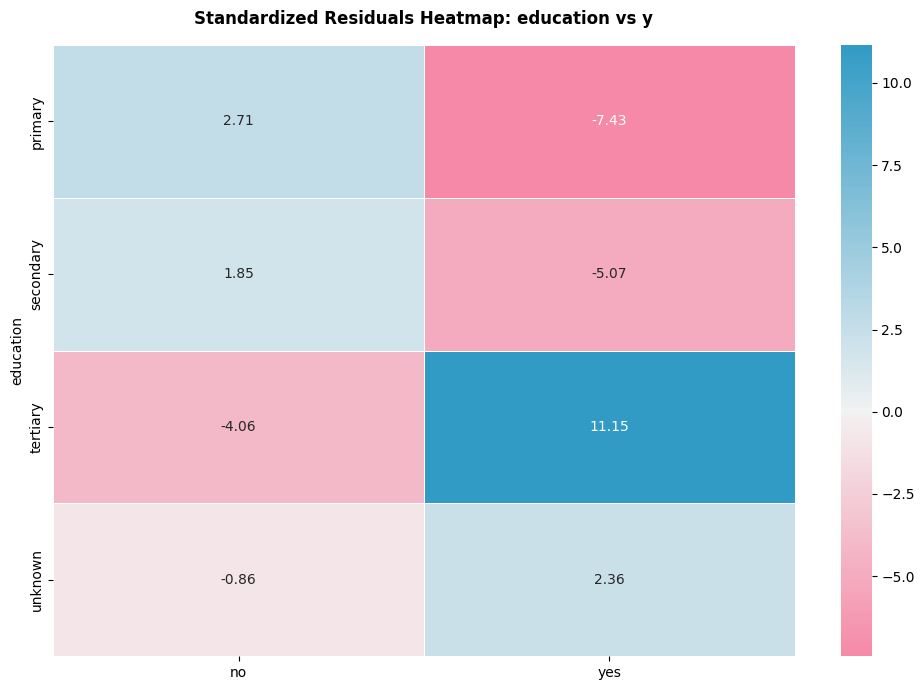

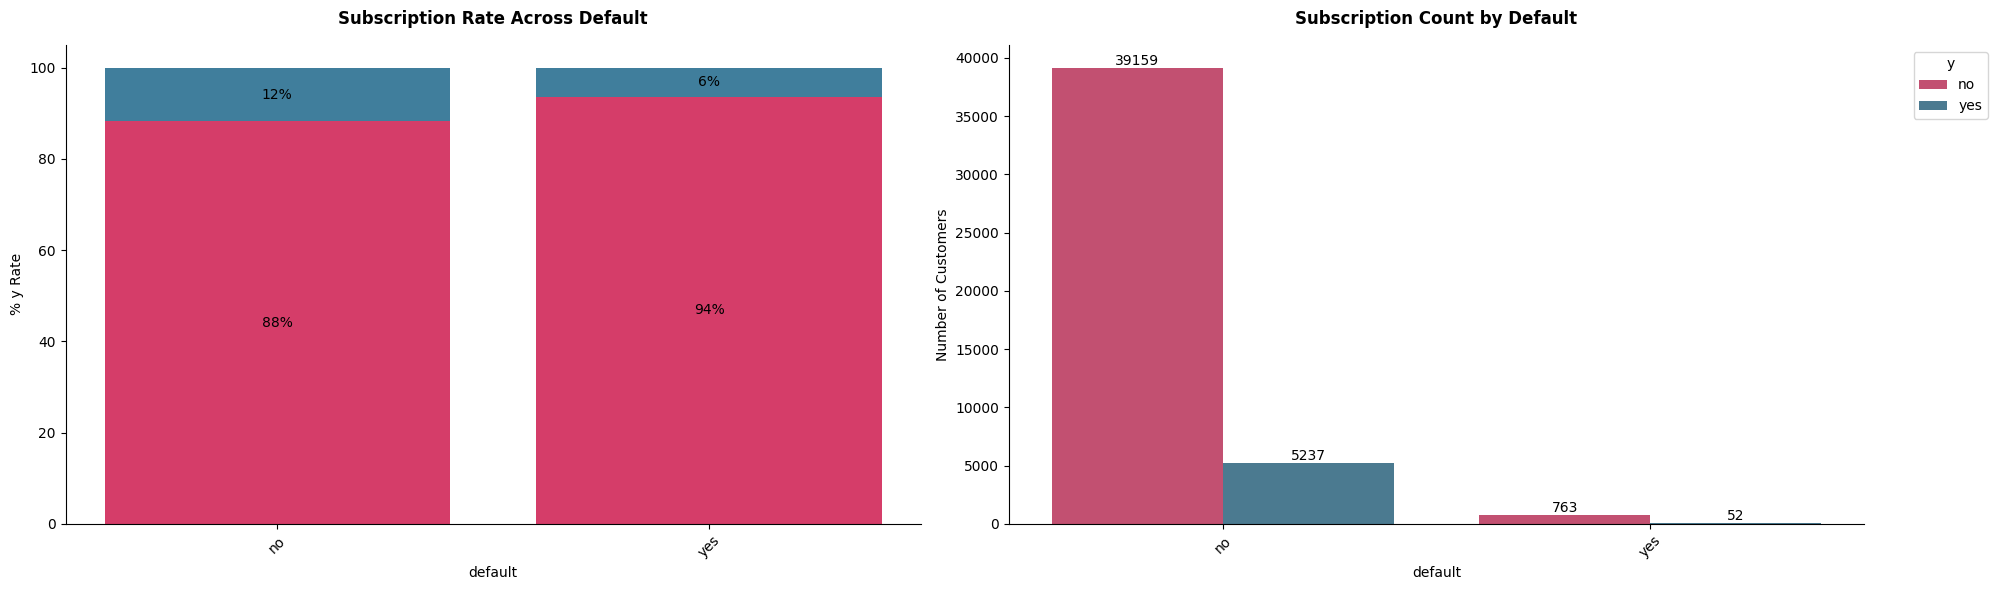

2026-03-09 14:11:21 | INFO     | Chi-Square Test of Independence: 'default' vs. 'y'...
2026-03-09 14:11:21 | INFO     | Chi-squared statistic: 22.202
2026-03-09 14:11:21 | INFO     | Degrees of freedom: 1
2026-03-09 14:11:21 | INFO     | p-value: 0.000002
2026-03-09 14:11:21 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-09 14:11:21 | INFO     | Variables 'default' and 'y' are statistically associated.
2026-03-09 14:11:21 | DEBUG    | Displaying standardized residuals heatmap.


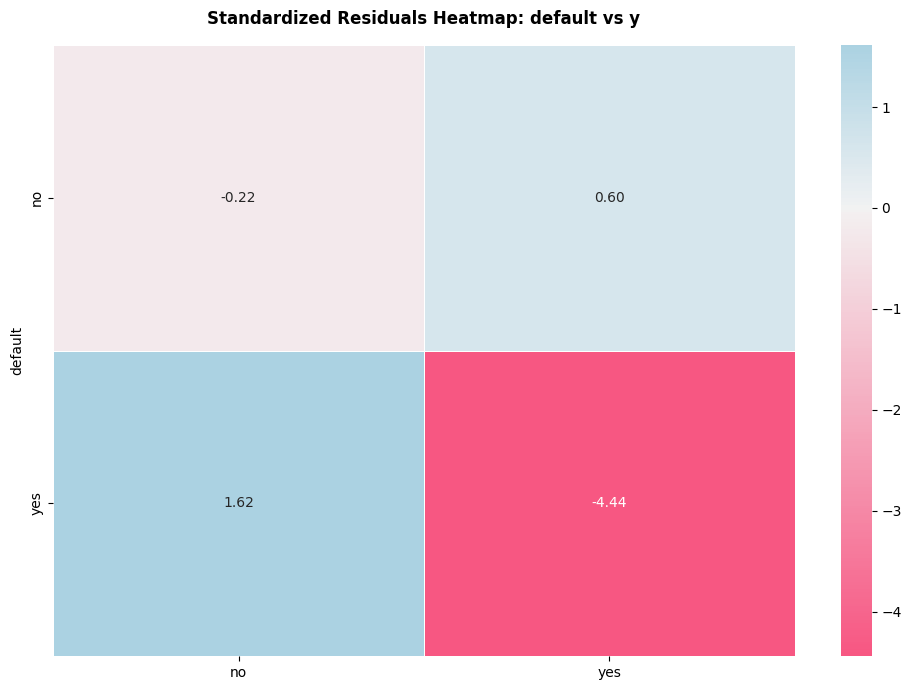

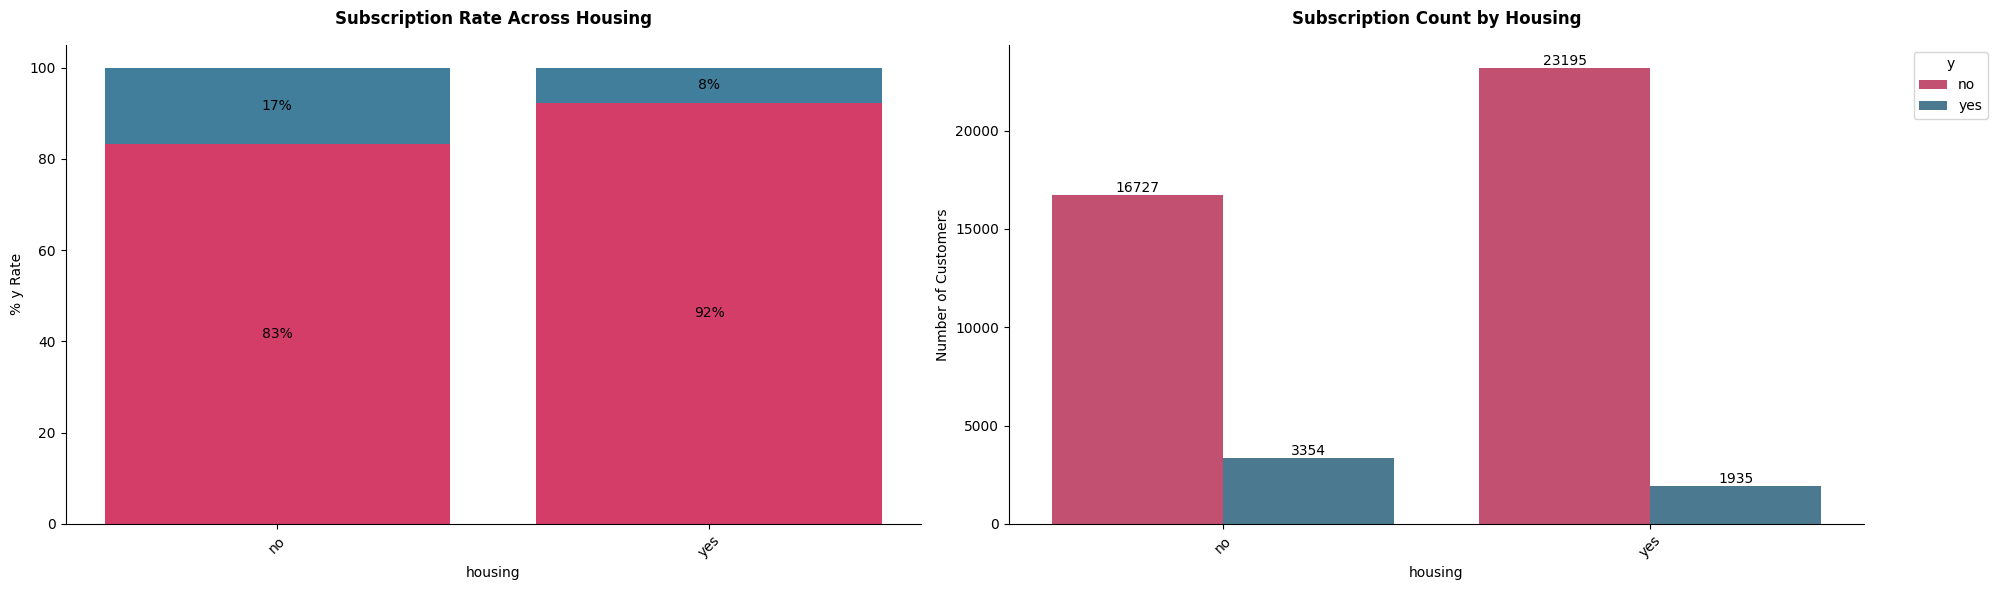

2026-03-09 14:11:22 | INFO     | Chi-Square Test of Independence: 'housing' vs. 'y'...
2026-03-09 14:11:22 | INFO     | Chi-squared statistic: 874.822
2026-03-09 14:11:22 | INFO     | Degrees of freedom: 1
2026-03-09 14:11:22 | INFO     | p-value: 0.000000
2026-03-09 14:11:22 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-09 14:11:22 | INFO     | Variables 'housing' and 'y' are statistically associated.
2026-03-09 14:11:22 | DEBUG    | Displaying standardized residuals heatmap.


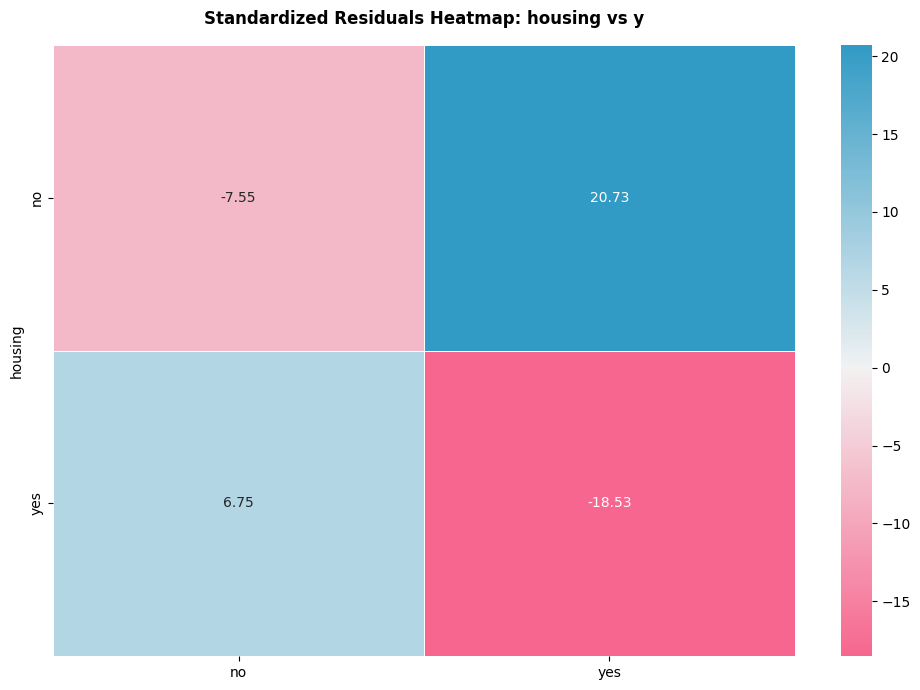

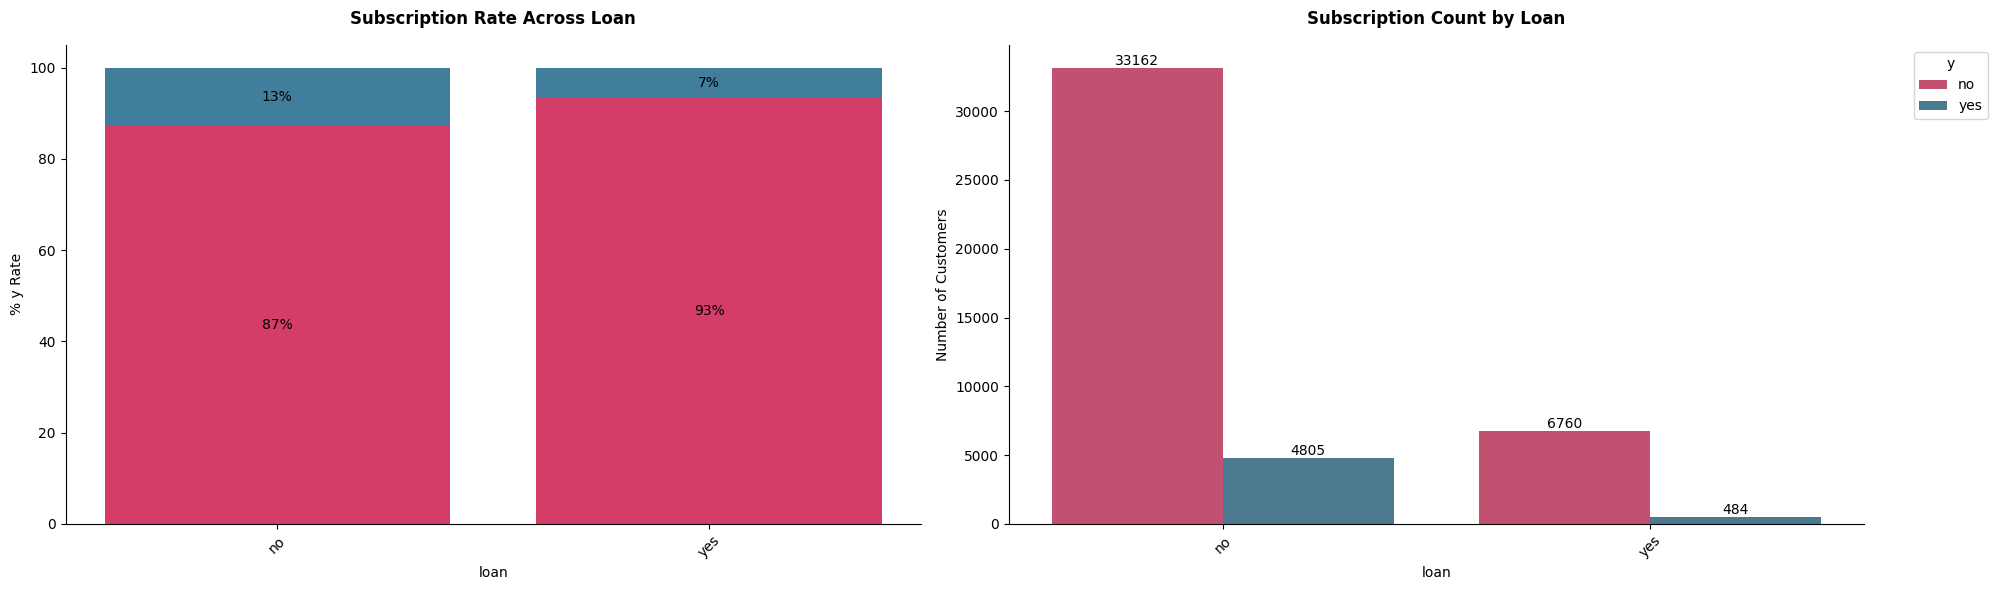

2026-03-09 14:11:22 | INFO     | Chi-Square Test of Independence: 'loan' vs. 'y'...
2026-03-09 14:11:22 | INFO     | Chi-squared statistic: 209.617
2026-03-09 14:11:22 | INFO     | Degrees of freedom: 1
2026-03-09 14:11:22 | INFO     | p-value: 0.000000
2026-03-09 14:11:22 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-09 14:11:22 | INFO     | Variables 'loan' and 'y' are statistically associated.
2026-03-09 14:11:22 | DEBUG    | Displaying standardized residuals heatmap.


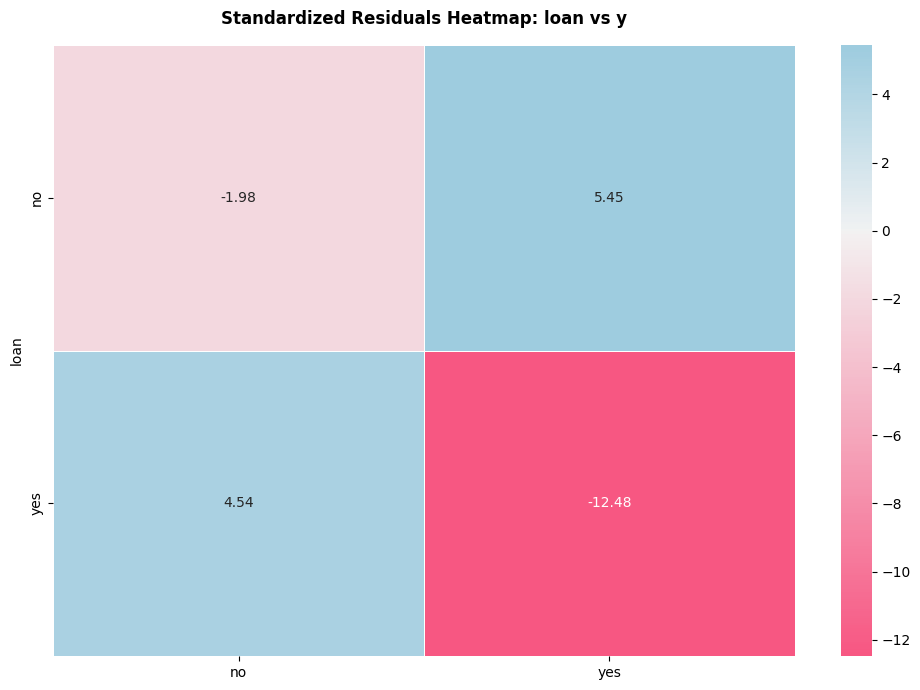

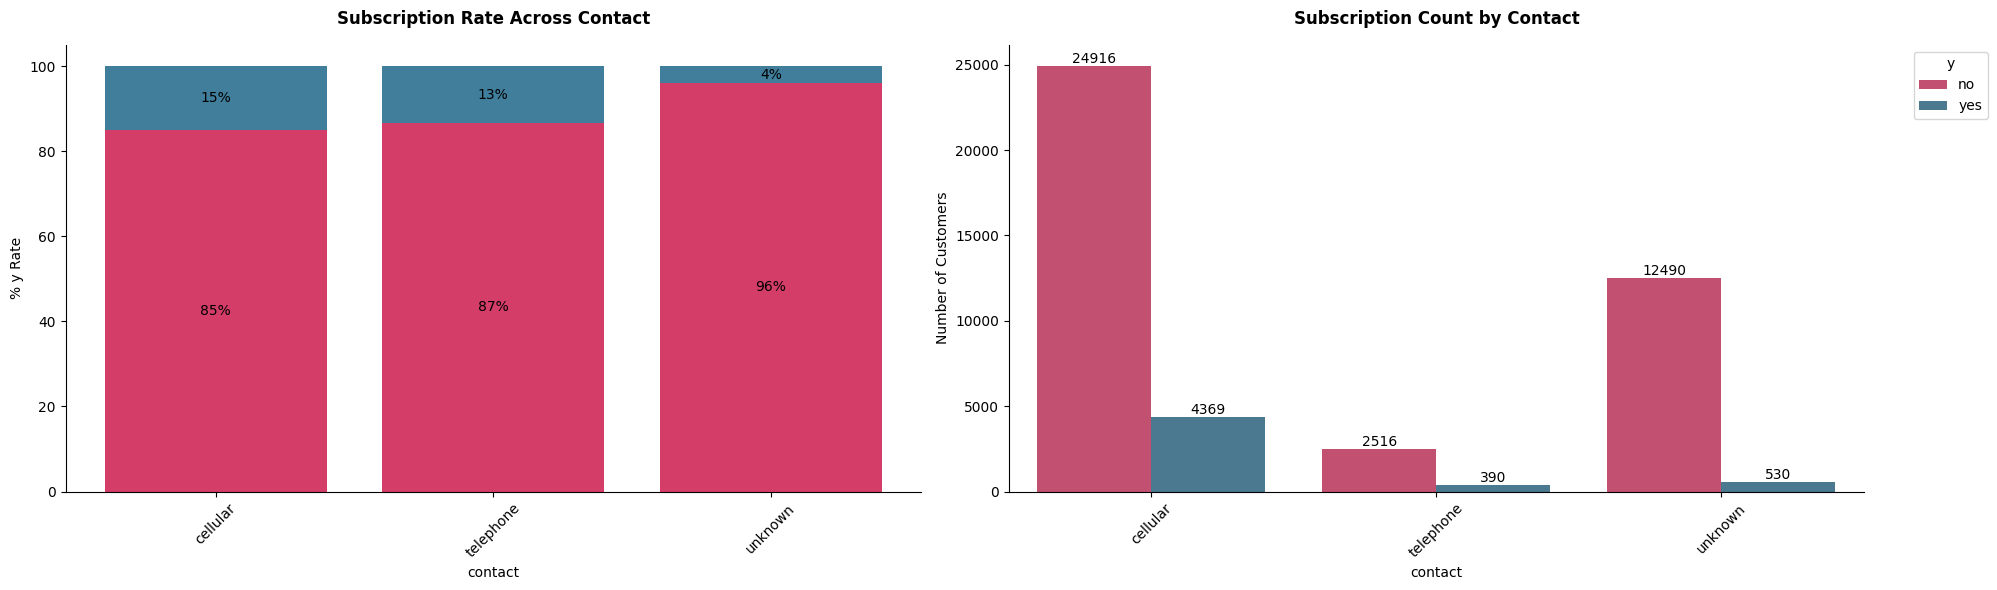

2026-03-09 14:11:23 | INFO     | Chi-Square Test of Independence: 'contact' vs. 'y'...
2026-03-09 14:11:23 | INFO     | Chi-squared statistic: 1035.714
2026-03-09 14:11:23 | INFO     | Degrees of freedom: 2
2026-03-09 14:11:23 | INFO     | p-value: 0.000000
2026-03-09 14:11:23 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-09 14:11:23 | INFO     | Variables 'contact' and 'y' are statistically associated.
2026-03-09 14:11:23 | DEBUG    | Displaying standardized residuals heatmap.


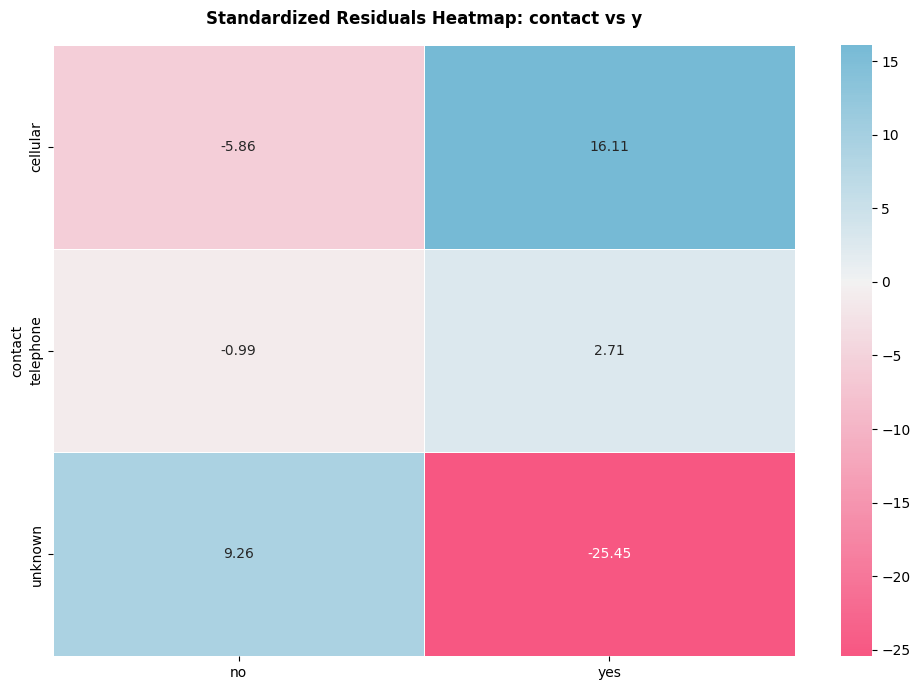

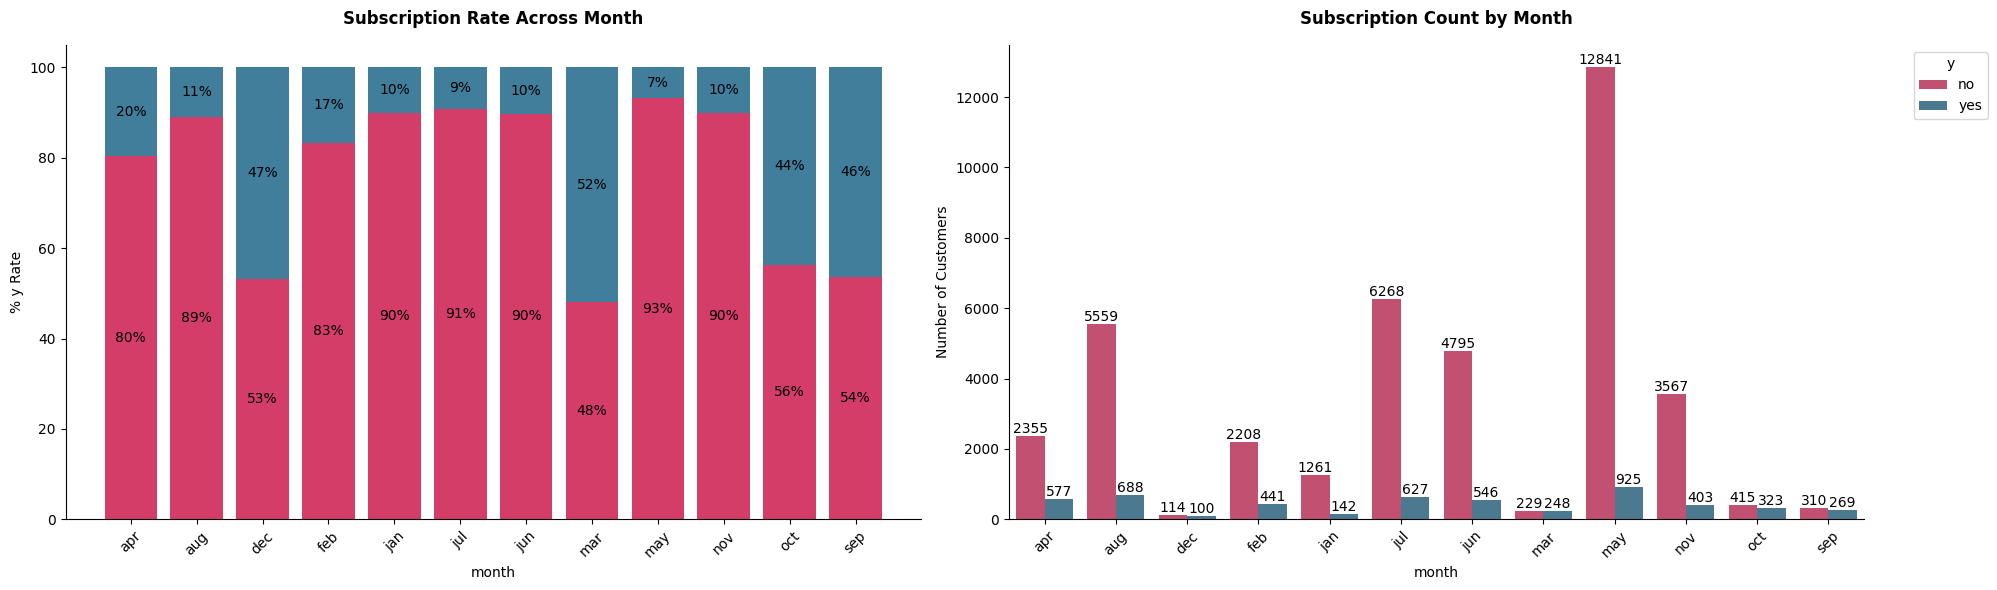

2026-03-09 14:11:23 | INFO     | Chi-Square Test of Independence: 'month' vs. 'y'...
2026-03-09 14:11:23 | INFO     | Chi-squared statistic: 3061.839
2026-03-09 14:11:23 | INFO     | Degrees of freedom: 11
2026-03-09 14:11:23 | INFO     | p-value: 0.000000
2026-03-09 14:11:23 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-09 14:11:23 | INFO     | Variables 'month' and 'y' are statistically associated.
2026-03-09 14:11:23 | DEBUG    | Displaying standardized residuals heatmap.


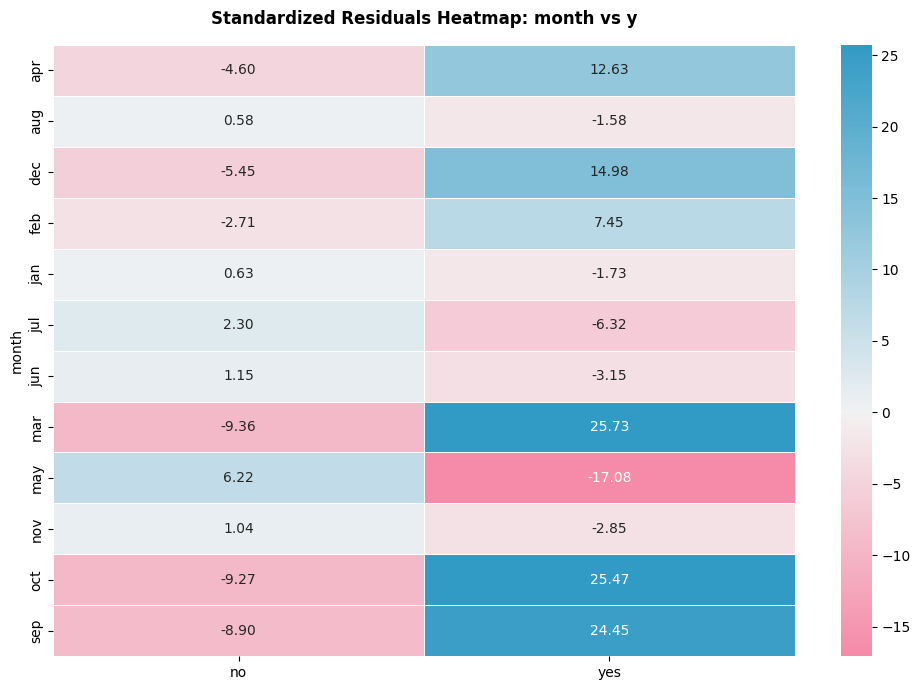

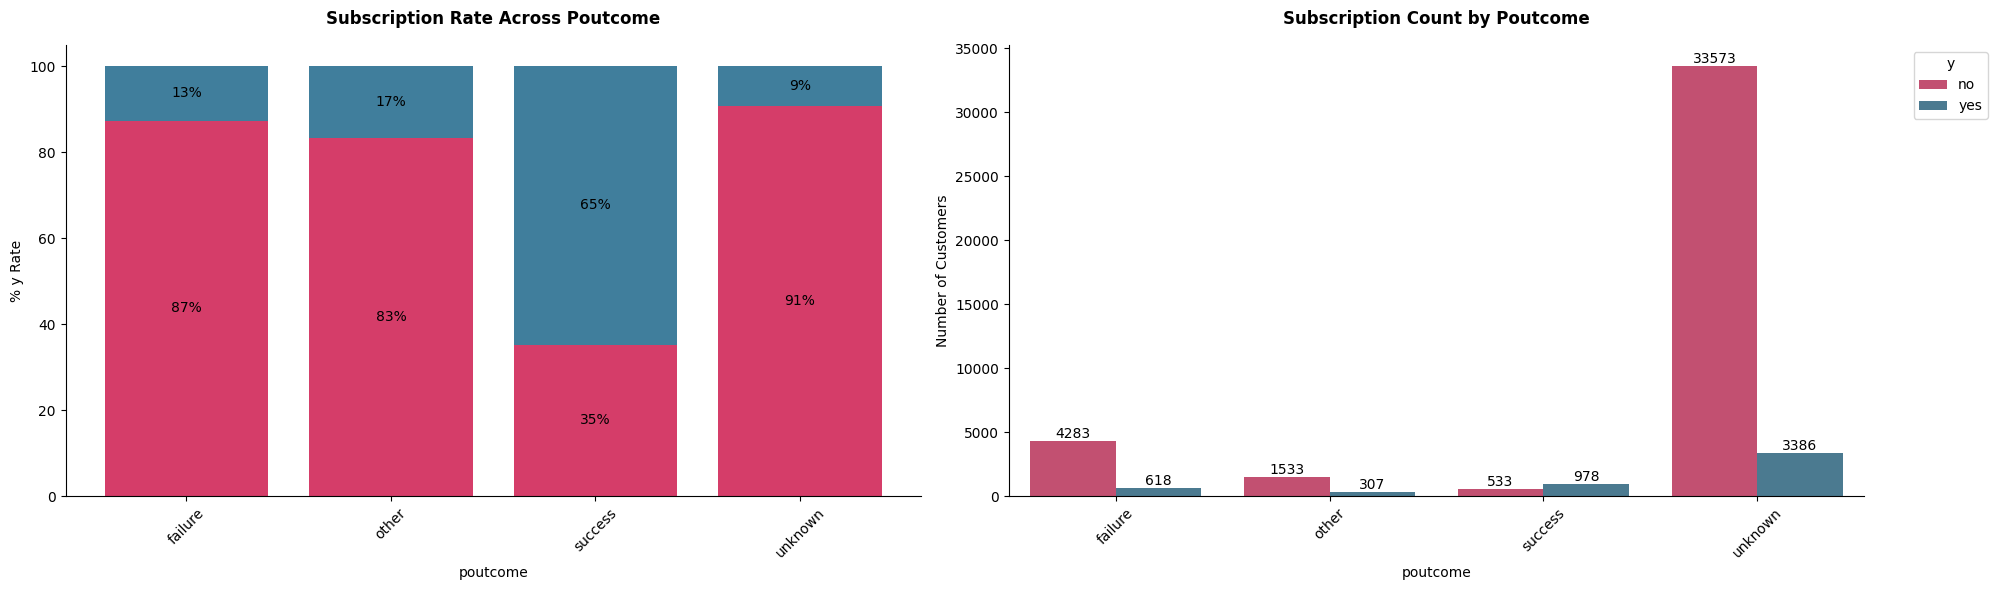

2026-03-09 14:11:24 | INFO     | Chi-Square Test of Independence: 'poutcome' vs. 'y'...
2026-03-09 14:11:24 | INFO     | Chi-squared statistic: 4391.507
2026-03-09 14:11:24 | INFO     | Degrees of freedom: 3
2026-03-09 14:11:24 | INFO     | p-value: 0.000000
2026-03-09 14:11:24 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-09 14:11:24 | INFO     | Variables 'poutcome' and 'y' are statistically associated.
2026-03-09 14:11:24 | DEBUG    | Displaying standardized residuals heatmap.


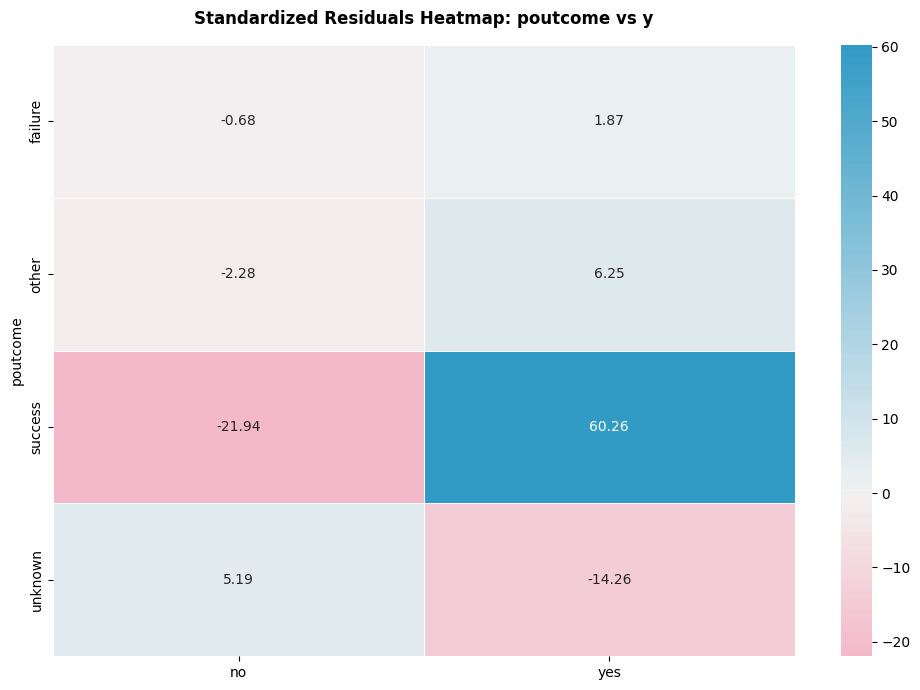

In [17]:
for feature in cat_features:
    StatUtils.analyze_categorical_feature_vs_target(cat = feature, target_feature=config["data"]["target_feature"],
                                                    logger=logger, df=df)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Insight for Categorical Features vs Subscription
</div>

`Job`  
Subscription rates vary by occupation. **Students, retirees, and management** show higher subscription rates, while **blue-collar and service jobs** tend to subscribe less.

`Marital Status`  
**Single customers** are more likely to subscribe, while **married and divorced groups** show lower engagement.

`Education`  
Customers with **tertiary education** are more likely to subscribe, whereas **primary and secondary education** groups show lower conversion rates.

`Default`  
Customers **without credit default history** are more likely to subscribe, while **defaulted customers** rarely subscribe.

`Housing & Personal Loan`  
Customers **without housing or personal loans** are more likely to subscribe, suggesting that **existing financial obligations reduce willingness to adopt new financial products**.

`Contact Method`  
**Cellular contact** is the most effective channel for generating subscriptions, while **unknown contact methods perform poorly**.

`Month`  
Subscription rates vary by month. **Sep, Oct, and Mar** show higher conversion, while **May–Jul** have lower effectiveness despite high contact volume.

`Previous Campaign Outcome (poutcome)`  
Customers with **previous successful campaign outcomes** have the highest likelihood of subscribing, making this **one of the strongest predictors**.

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Overall Picture</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Overall Picture
    </h1>
</div>

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Overall Picuture
</div>

| Feature       | Key Insight                                                                                                     |
| ------------- | --------------------------------------------------------------------------------------------------------------- |
| **job**       | Higher subscription among **students, retirees, and management**; lower among **blue-collar and service jobs**. |
| **marital**   | **Single customers** are more responsive; **married and divorced** show lower subscription rates.               |
| **education** | **Tertiary education** correlates with higher subscription likelihood.                                          |
| **default**   | Customers **without credit default** are more likely to subscribe.                                              |
| **housing**   | Customers **without housing loans** subscribe more frequently.                                                  |
| **loan**      | Customers **without personal loans** are more likely to subscribe.                                              |
| **contact**   | **Cellular contact** is the most effective communication channel.                                               |
| **month**     | **Sep, Oct, Mar** show higher conversions; **May–Jul** underperform despite many contacts.                      |
| **poutcome**  | **Previous campaign success** strongly increases subscription probability.                                      |
| **age**       | Age distribution differs slightly between groups but shows limited impact.                                      |
| **balance**   | Subscribers tend to have **higher account balances**.                                                           |
| **day**       | **Earlier contact in the month** slightly increases subscription likelihood.                                    |
| **duration**  | **Longer call duration** strongly relates to higher subscription rates.                                         |
| **campaign**  | **More contact attempts** often occur for non-subscribers.                                                      |
| **pdays**     | **Recent follow-ups** increase the chance of subscription.                                                      |
| **previous**  | **More prior contacts** slightly increase subscription probability.                                             |

</div>


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Pre-processing</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Pre-processing
    </h1>
</div>

## Handle skewness

In [18]:
skew_feature = DataValidator.check_skewness(data=df, dataset_name="Bank Marketing", 
                                            numerical_features=num_features, logger=logger)
logger.info("-" * 80)
logger.info("Checking skewness successfully completed the dataset.")

2026-03-09 14:11:24 | INFO     | Skewness analysis for Bank Marketing
2026-03-09 14:11:24 | INFO     | Total numerical features checked: 7
2026-03-09 14:11:24 | DEBUG    | ----------------------------------------------------------------------
2026-03-09 14:11:24 | DEBUG    | Feature                        | Skewness  | Remark
2026-03-09 14:11:24 | DEBUG    | ----------------------------------------------------------------------
2026-03-09 14:11:24 | DEBUG    | previous                       |  +41.8465 | Highly skewed
2026-03-09 14:11:24 | DEBUG    | balance                        |   +8.3603 | Highly skewed
2026-03-09 14:11:24 | DEBUG    | campaign                       |   +4.8987 | Highly skewed
2026-03-09 14:11:24 | DEBUG    | duration                       |   +3.1443 | Highly skewed
2026-03-09 14:11:24 | DEBUG    | pdays                          |   +2.6157 | Highly skewed
2026-03-09 14:11:24 | DEBUG    | age                            |   +0.6848 | Moderately skewed
2026-03-09 1

In [19]:
processed_df, transformed_columns, sparse_columns, skewed_columns = FeatureUtils.fea_HandleSkewedFeatures(df=df, num_features=skew_feature, logger=logger)

2026-03-09 14:11:24 | INFO     | Starting skewed feature handling
2026-03-09 14:11:24 | DEBUG    | Total numerical features provided: 6
2026-03-09 14:11:24 | DEBUG    | Excluded columns: []
2026-03-09 14:11:24 | INFO     | Scanning 6 numerical columns
2026-03-09 14:11:24 | INFO     | Detected 6 skewed features
2026-03-09 14:11:24 | DEBUG    | Processing column: age
2026-03-09 14:11:24 | INFO     | age: applying Yeo-Johnson transformation
2026-03-09 14:11:24 | DEBUG    | Processing column: balance
2026-03-09 14:11:24 | INFO     | balance: applying Yeo-Johnson transformation
2026-03-09 14:11:24 | DEBUG    | Processing column: pdays
2026-03-09 14:11:24 | INFO     | pdays: applying Yeo-Johnson transformation
2026-03-09 14:11:24 | DEBUG    | Processing column: duration
2026-03-09 14:11:24 | INFO     | duration: applying Yeo-Johnson transformation
2026-03-09 14:11:24 | DEBUG    | Processing column: campaign
2026-03-09 14:11:24 | INFO     | campaign: applying Yeo-Johnson transformation
2026-0

In [20]:
num_features = ["PT_age", "PT_balance", "day", "PT_duration", "PT_campaign", "PT_pdays", "PT_previous"]
skew_feature = DataValidator.check_skewness(data=processed_df, dataset_name="Bank Marketing", 
                                            numerical_features=num_features, logger=logger)
logger.info("-" * 80)
logger.info("Checking skewness successfully completed the dataset.")

2026-03-09 14:11:24 | INFO     | Skewness analysis for Bank Marketing
2026-03-09 14:11:24 | INFO     | Total numerical features checked: 7
2026-03-09 14:11:24 | DEBUG    | ----------------------------------------------------------------------
2026-03-09 14:11:24 | DEBUG    | Feature                        | Skewness  | Remark
2026-03-09 14:11:24 | DEBUG    | ----------------------------------------------------------------------
2026-03-09 14:11:24 | DEBUG    | PT_previous                    |   +1.6461 | Highly skewed
2026-03-09 14:11:24 | DEBUG    | PT_pdays                       |   +1.6452 | Highly skewed
2026-03-09 14:11:24 | DEBUG    | PT_balance                     |   +1.0986 | Highly skewed
2026-03-09 14:11:24 | DEBUG    | PT_campaign                    |   +0.2309 | Approximately symmetric
2026-03-09 14:11:24 | DEBUG    | day                            |   +0.0931 | Approximately symmetric
2026-03-09 14:11:24 | DEBUG    | PT_duration                    |   +0.0180 | Approximat

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Overall Picuture
</div>

**Observations from the Skewness Table (`processed_df`):**

**Skewed**:

* The features `pdays`, `previous`, `balance`, `campaign`, `duration`, `age` exhibit skewness.

**Approximately Symmetric**:

* Several features, such as:

  * `PT_campaign`, `PT_duration`, `PT_age` close to zero.
  * `PT_pdays`, `PT_previous`, and `PT_balance` remain skewed, but their skewness has been significantly reduced compared to before applying the Yeo-Johnson method.
  * This indicates that **Yeo-Johnson transformation was effective** for these features.

</div>

## Re-check Outlier

In [21]:
logger.info("Start checking outlier dataset")
logger.info("-" * 80)
outlier_data = DataValidator.checkOutlier(df=processed_df, dataset_name="Bank Marketing", 
                                          list_feature=num_features, logger=logger)
logger.info("-" * 80)
logger.info("Outlier checking successfully completed across datasets.")

2026-03-09 14:11:24 | INFO     | Start checking outlier dataset
2026-03-09 14:11:24 | INFO     | --------------------------------------------------------------------------------
2026-03-09 14:11:24 | INFO     | Checking outliers for Bank Marketing...
2026-03-09 14:11:24 | INFO     | --------------------------------------------------------------------------------
2026-03-09 14:11:24 | WARNING  | [Bank Marketing] PT_age: 59 outliers detected (lower=-2.920, upper=2.974)
2026-03-09 14:11:24 | WARNING  | [Bank Marketing] PT_balance: 5,292 outliers detected (lower=-1.216, upper=1.002)
2026-03-09 14:11:24 | DEBUG    | [Bank Marketing] day: No outliers detected
2026-03-09 14:11:24 | WARNING  | [Bank Marketing] PT_duration: 913 outliers detected (lower=-2.487, upper=2.486)
2026-03-09 14:11:24 | DEBUG    | [Bank Marketing] PT_campaign: No outliers detected
2026-03-09 14:11:24 | WARNING  | [Bank Marketing] PT_pdays: 8,257 outliers detected (lower=-0.473, upper=-0.473)
2026-03-09 14:11:24 | WARNIN

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Overall Picuture
</div>

**Observation**

* After applying **Yeo-Johnson transformation**, several features still show outliers.
* Notable cases:

  * `PT_age`: 59 outliers
  * `PT_balance`: 5,292 outliers
  * `PT_duration`: 913 outliers
  * `PT_pdays` & `PT_previous`: 8,257 outliers

**Key Insight**

* Power transformation reduces **skewness** but **does not eliminate outliers**.
* Extremely concentrated distributions (e.g., `pdays`, `previous`) lead to large numbers of detected outliers.

**Decision**

* Instead of removing outliers, apply **Robust Scaling** to reduce their impact on model training.

</div>

## Create Test Set

In [22]:
X = processed_df.drop(columns=config["data"]["target_feature"])
y = processed_df[config["data"]["target_feature"]].map({"no": 0, "yes": 1})

split = StratifiedShuffleSplit(n_splits=config["split"]["n_splits"], test_size=config["split"]["test_size"], 
                               random_state=config["reproducibility"]["random_state"])
for train_idx, test_idx in split.split(X, y):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

## Scale and Encode

In [23]:
list_feature_num_robust = ["PT_age", "PT_balance", "PT_duration", "PT_pdays", "PT_previous"]
list_feature_num_stand = ["day", "PT_campaign"]
list_feature_cat_onehot = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "poutcome"]

num_robust_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

num_stand_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_onehot_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num_robust", num_robust_transformer, list_feature_num_robust),
    ("num_standard", num_stand_transformer, list_feature_num_stand),
    ("cat_onehot", cat_onehot_transformer, list_feature_cat_onehot)
])

preprocessor.fit(X_train)
X_train_prepared = preprocessor.transform(X_train)
list_feature_prepared = preprocessor.get_feature_names_out().tolist()
clean_features = [col.replace("num_standard__", "").replace("num_robust__", "").replace("cat_onehot__", "").replace("PT_", "") for col in list_feature_prepared]
clean_features

['age',
 'balance',
 'duration',
 'pdays',
 'previous',
 'day',
 'campaign',
 'job_admin.',
 'job_blue-collar',
 'job_entrepreneur',
 'job_housemaid',
 'job_management',
 'job_retired',
 'job_self-employed',
 'job_services',
 'job_student',
 'job_technician',
 'job_unemployed',
 'job_unknown',
 'marital_divorced',
 'marital_married',
 'marital_single',
 'education_primary',
 'education_secondary',
 'education_tertiary',
 'education_unknown',
 'default_no',
 'default_yes',
 'housing_no',
 'housing_yes',
 'loan_no',
 'loan_yes',
 'contact_cellular',
 'contact_telephone',
 'contact_unknown',
 'month_apr',
 'month_aug',
 'month_dec',
 'month_feb',
 'month_jan',
 'month_jul',
 'month_jun',
 'month_mar',
 'month_may',
 'month_nov',
 'month_oct',
 'month_sep',
 'poutcome_failure',
 'poutcome_other',
 'poutcome_success',
 'poutcome_unknown']

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Metric</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Metric
    </h1>
</div>


**AUC-ROC Overview**

**AUC-ROC** evaluates a model’s ability to **distinguish between two classes**.

* **ROC curve** plots **TPR vs FPR**
* **AUC** = Area under ROC curve → **ranking quality of predictions**

**Why AUC-ROC?**

* Robust to **class imbalance**
* Measures **ranking ability**, not fixed threshold (0.5)
* Common metric in **credit risk & fraud prediction**

> Higher AUC → better separation between *Paid* vs *Default*

**Interpretation**

| AUC Score     | Meaning                  |
| ------------- | ------------------------ |
| **1.0**       | Perfect model            |
| **0.9+**      | Excellent discrimination |
| **0.7 – 0.9** | Good                     |
| **0.5**       | Random guessing          |
| **< 0.5**     | Worse than random        |

(Source: [ROC AUC](https://en.wikipedia.org/wiki/Receiver_operating_characteristic))

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Comparison Models</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Comparison Models
    </h1>
</div>

2026-03-09 14:11:25 | INFO     | Starting model benchmarking using cross-validation
2026-03-09 14:11:25 | INFO     | Evaluating model: LinearSVC
2026-03-09 14:11:28 | INFO     | LinearSVC | mean=0.9095 | std=0.0032
2026-03-09 14:11:28 | INFO     | ********************************************************************************
2026-03-09 14:11:28 | INFO     | Evaluating model: SVC
2026-03-09 14:12:24 | INFO     | SVC | mean=0.9271 | std=0.0003
2026-03-09 14:12:24 | INFO     | ********************************************************************************
2026-03-09 14:12:24 | INFO     | Evaluating model: KNeighborsClassifier
2026-03-09 14:12:27 | INFO     | KNeighborsClassifier | mean=0.8164 | std=0.0068
2026-03-09 14:12:27 | INFO     | ********************************************************************************
2026-03-09 14:12:27 | INFO     | Evaluating model: GaussianNB
2026-03-09 14:12:29 | INFO     | GaussianNB | mean=0.7844 | std=0.0036
2026-03-09 14:12:29 | INFO     | *****

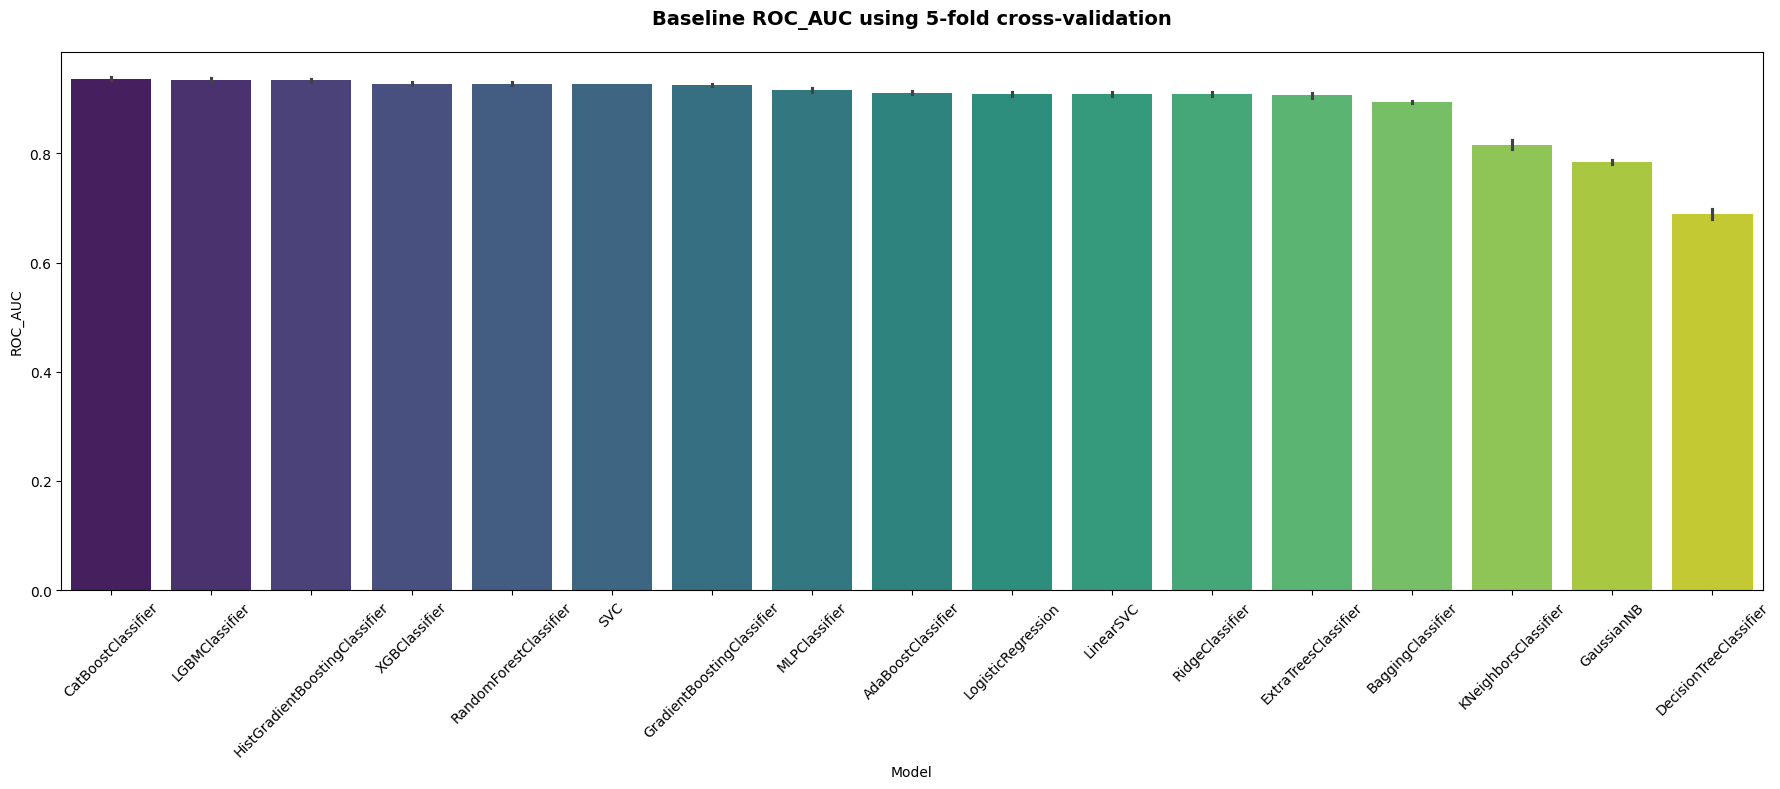

None

In [24]:
random_state = config["reproducibility"]["random_state"]
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
models = [
    LinearSVC(random_state=random_state, class_weight="balanced"),
    SVC(random_state=random_state, class_weight="balanced"),
    KNeighborsClassifier(),
    GaussianNB(),
    LogisticRegression(random_state=random_state, class_weight="balanced"),
    DecisionTreeClassifier(random_state=random_state, class_weight="balanced"),
    RandomForestClassifier(random_state=random_state, class_weight="balanced"),
    ExtraTreesClassifier(random_state=random_state, class_weight="balanced"),
    AdaBoostClassifier(random_state=random_state),
    XGBClassifier(random_state=random_state, scale_pos_weight=scale_pos_weight),
    MLPClassifier(random_state=random_state),
    GradientBoostingClassifier(random_state=random_state),
    RidgeClassifier(random_state=random_state, class_weight="balanced"),
    CatBoostClassifier(verbose=False, random_seed=random_state, auto_class_weights="Balanced"),
    BaggingClassifier(random_state=random_state),
    LGBMClassifier(random_state=random_state, verbosity=-1, class_weight="balanced"),
    HistGradientBoostingClassifier(random_state=random_state, class_weight="balanced")
]

display(benchmark_models(models=models, X=X_train_prepared, y=y_train, logger=logger, cv=kfold, plot_result=True))

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Hyperparameter tuning</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Hyperparameter tuning
    </h1>
</div>

## CatBoostClassifier

In [25]:
study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(
    lambda trial: objective_catboost(trial, X_train_prepared, y_train, logger),
    n_trials=10, show_progress_bar=True
)

  0%|          | 0/10 [00:00<?, ?it/s]

2026-03-09 14:14:45 | INFO     | Trial 0 finished | Mean AUC: 0.93027
2026-03-09 14:15:45 | INFO     | Trial 1 finished | Mean AUC: 0.93865
2026-03-09 14:16:41 | INFO     | Trial 2 finished | Mean AUC: 0.93718
2026-03-09 14:17:44 | INFO     | Trial 3 finished | Mean AUC: 0.93762
2026-03-09 14:18:46 | INFO     | Trial 4 finished | Mean AUC: 0.93414
2026-03-09 14:19:58 | INFO     | Trial 5 finished | Mean AUC: 0.93475
2026-03-09 14:21:56 | INFO     | Trial 6 finished | Mean AUC: 0.92830
2026-03-09 14:23:59 | INFO     | Trial 7 finished | Mean AUC: 0.93898
2026-03-09 14:24:31 | INFO     | Trial 8 finished | Mean AUC: 0.93656
2026-03-09 14:25:23 | INFO     | Trial 9 finished | Mean AUC: 0.93506


2026-03-09 14:25:23 | INFO     | Starting OOF training with CatBoostClassifier
2026-03-09 14:25:23 | INFO     | Fold 1/5
2026-03-09 14:25:46 | INFO     | Fold 1 AUC: 0.93662
2026-03-09 14:25:46 | INFO     | Fold 2/5
2026-03-09 14:26:10 | INFO     | Fold 2 AUC: 0.93701
2026-03-09 14:26:10 | INFO     | Fold 3/5
2026-03-09 14:26:34 | INFO     | Fold 3 AUC: 0.94086
2026-03-09 14:26:34 | INFO     | Fold 4/5
2026-03-09 14:26:59 | INFO     | Fold 4 AUC: 0.94131
2026-03-09 14:26:59 | INFO     | Fold 5/5
2026-03-09 14:27:24 | INFO     | Fold 5 AUC: 0.93869
2026-03-09 14:27:24 | INFO     | OOF training completed
2026-03-09 14:27:24 | INFO     | OOF AUC: 0.93882
2026-03-09 14:27:24 | INFO     | Fold AUCs: [0.9366248551139771, 0.9370134383174126, 0.9408570278803849, 0.9413077168791071, 0.9386949184976429]


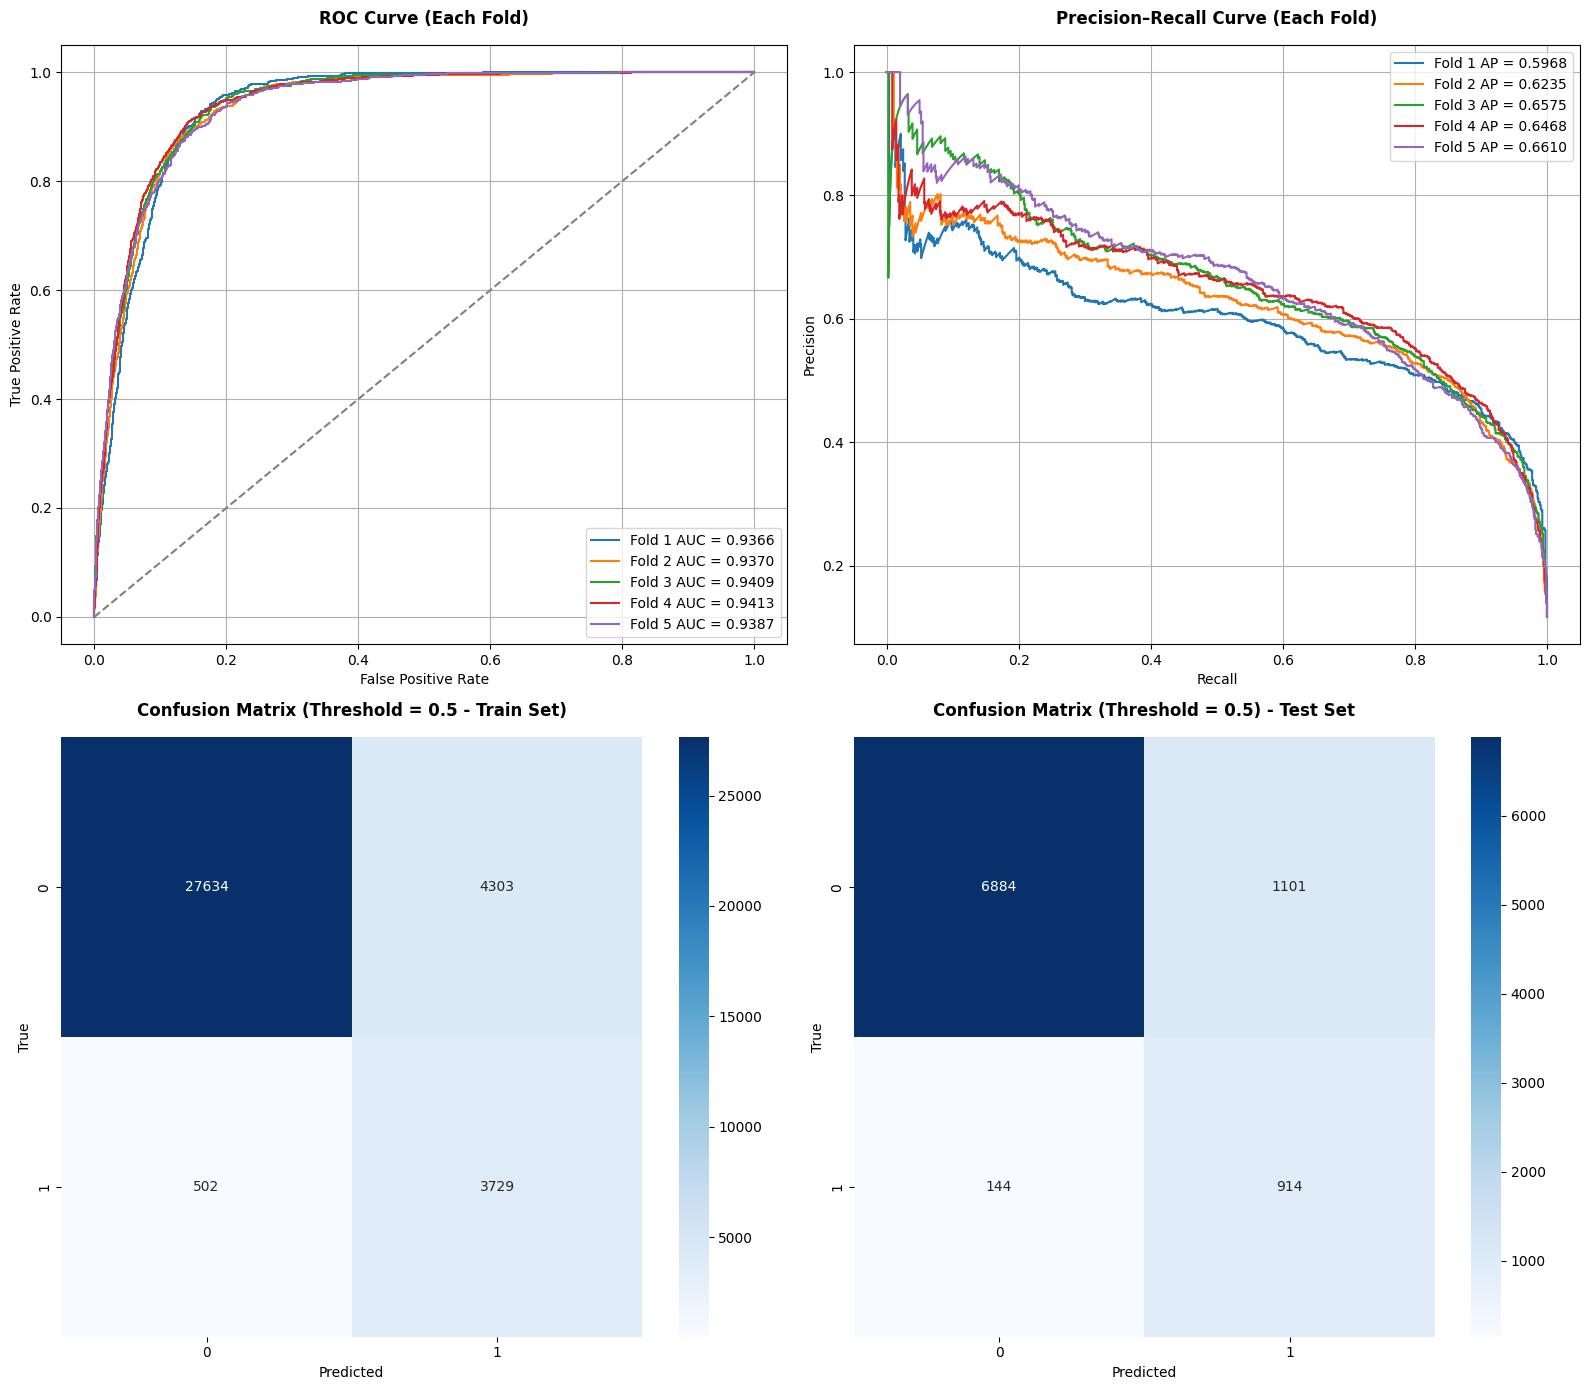

In [26]:
model_cb = CatBoostClassifier(**study_cat.best_params, loss_function="Logloss", auto_class_weights="Balanced", random_seed=random_state,
                              verbose = 0, thread_count=-1, eval_metric="AUC", grow_policy="SymmetricTree", task_type="CPU",
                              allow_writing_files = False)
X_test_prepared = preprocessor.transform(X_test)
oof_pred_cb, test_pred_cb, fold_auc_cb, fold_models_cb = run_oof(model = model_cb, X = X_train_prepared, y = y_train.values, 
                                                                 X_test = X_test_prepared, y_test=y_test, logger=logger)

## LGBMClassifier

In [27]:
study_lgbm = optuna.create_study(direction="maximize")
study_lgbm.optimize(lambda trial: objective_lgbm(trial, X_train_prepared, y_train, logger),
    n_trials=10, show_progress_bar=True
)

  0%|          | 0/10 [00:00<?, ?it/s]

2026-03-09 14:30:17 | INFO     | Trial 0 finished | Mean AUC: 0.93542
2026-03-09 14:31:02 | INFO     | Trial 1 finished | Mean AUC: 0.93578
2026-03-09 14:32:57 | INFO     | Trial 2 finished | Mean AUC: 0.93527
2026-03-09 14:33:35 | INFO     | Trial 3 finished | Mean AUC: 0.93549
2026-03-09 14:34:34 | INFO     | Trial 4 finished | Mean AUC: 0.93566
2026-03-09 14:35:01 | INFO     | Trial 5 finished | Mean AUC: 0.93571
2026-03-09 14:35:53 | INFO     | Trial 6 finished | Mean AUC: 0.93496
2026-03-09 14:37:26 | INFO     | Trial 7 finished | Mean AUC: 0.93308
2026-03-09 14:38:07 | INFO     | Trial 8 finished | Mean AUC: 0.93586
2026-03-09 14:39:16 | INFO     | Trial 9 finished | Mean AUC: 0.93530


2026-03-09 14:39:16 | INFO     | Starting OOF training with LGBMClassifier
2026-03-09 14:39:16 | INFO     | Fold 1/5
2026-03-09 14:39:16 | INFO     | Fold 1 AUC: 0.92557
2026-03-09 14:39:16 | INFO     | Fold 2/5
2026-03-09 14:39:16 | INFO     | Fold 2 AUC: 0.92740
2026-03-09 14:39:16 | INFO     | Fold 3/5
2026-03-09 14:39:17 | INFO     | Fold 3 AUC: 0.92894
2026-03-09 14:39:17 | INFO     | Fold 4/5
2026-03-09 14:39:17 | INFO     | Fold 4 AUC: 0.93253
2026-03-09 14:39:17 | INFO     | Fold 5/5
2026-03-09 14:39:17 | INFO     | Fold 5 AUC: 0.92849
2026-03-09 14:39:17 | INFO     | OOF training completed
2026-03-09 14:39:17 | INFO     | OOF AUC: 0.92838
2026-03-09 14:39:17 | INFO     | Fold AUCs: [0.9255678125800297, 0.9274022953794867, 0.9289351211294933, 0.9325288031503116, 0.928485146950014]


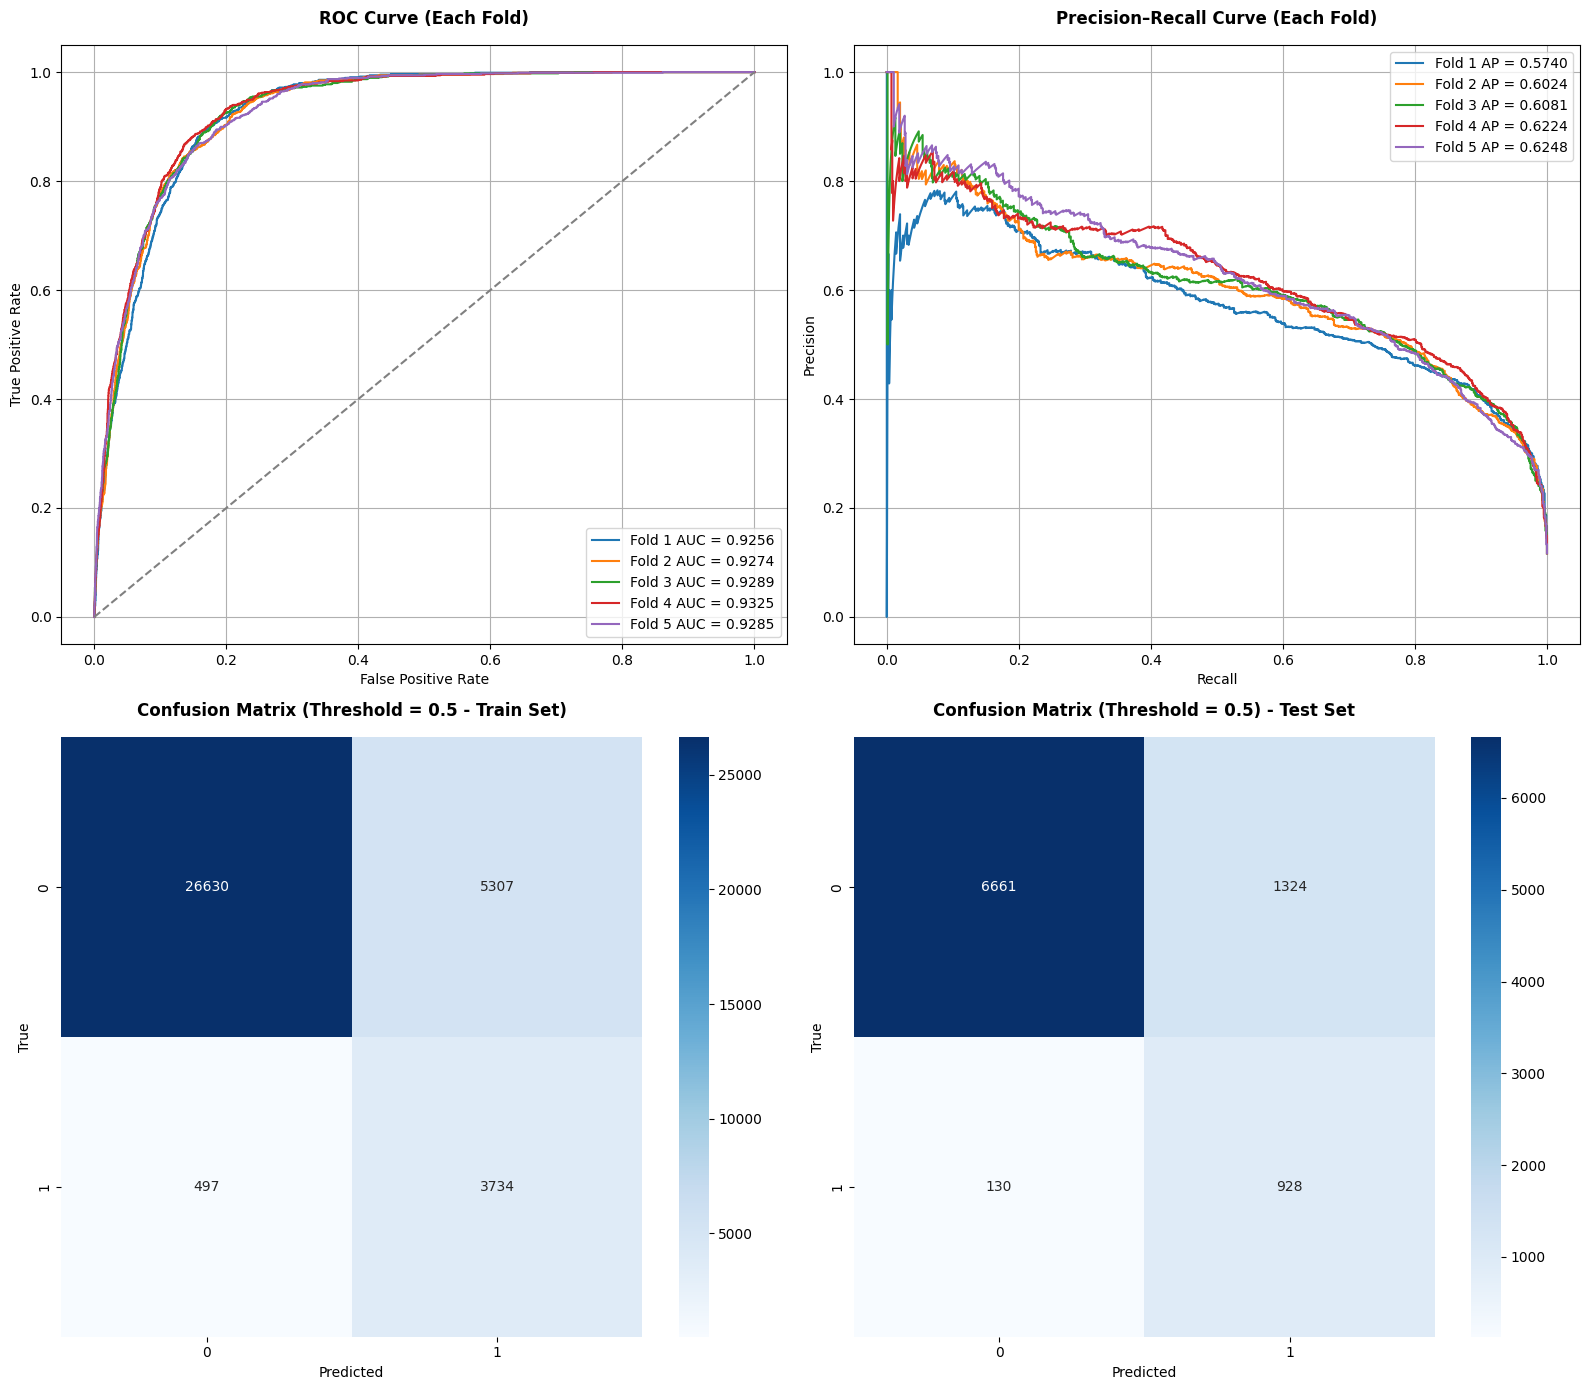

In [28]:
model_lgbm = LGBMClassifier(**study_lgbm.best_params, objective="binary", metric="auc",
                          verbosity=-1, n_jobs=-1, boosting_type="gbdt",
                          class_weight="balanced", random_state=random_state)
oof_pred_lgbm, test_pred_lgbm, fold_auc_lgbm, fold_models_lgbm = run_oof(model = model_lgbm, X = X_train_prepared, y = y_train.values, 
                                                                         X_test = X_test_prepared, y_test=y_test, logger=logger)

## HistGradientBoostingClassifier

In [29]:
study_hgbc = optuna.create_study(direction="maximize")
study_hgbc.optimize(lambda trial: objective_histgb(trial, X_train_prepared, y_train, logger),
    n_trials=10, show_progress_bar=True
)

  0%|          | 0/10 [00:00<?, ?it/s]

2026-03-09 14:39:33 | INFO     | Trial 0 finished | Mean AUC: 0.93420
2026-03-09 14:40:05 | INFO     | Trial 1 finished | Mean AUC: 0.93232
2026-03-09 14:40:17 | INFO     | Trial 2 finished | Mean AUC: 0.93383
2026-03-09 14:40:42 | INFO     | Trial 3 finished | Mean AUC: 0.93300
2026-03-09 14:40:54 | INFO     | Trial 4 finished | Mean AUC: 0.93325
2026-03-09 14:41:08 | INFO     | Trial 5 finished | Mean AUC: 0.93544
2026-03-09 14:41:16 | INFO     | Trial 6 finished | Mean AUC: 0.93466
2026-03-09 14:41:24 | INFO     | Trial 7 finished | Mean AUC: 0.93285
2026-03-09 14:41:31 | INFO     | Trial 8 finished | Mean AUC: 0.93400
2026-03-09 14:41:51 | INFO     | Trial 9 finished | Mean AUC: 0.93399


2026-03-09 14:41:51 | INFO     | Starting OOF training with HistGradientBoostingClassifier
2026-03-09 14:41:51 | INFO     | Fold 1/5
2026-03-09 14:41:55 | INFO     | Fold 1 AUC: 0.93325
2026-03-09 14:41:55 | INFO     | Fold 2/5
2026-03-09 14:41:58 | INFO     | Fold 2 AUC: 0.93436
2026-03-09 14:41:58 | INFO     | Fold 3/5
2026-03-09 14:42:01 | INFO     | Fold 3 AUC: 0.93367
2026-03-09 14:42:01 | INFO     | Fold 4/5
2026-03-09 14:42:03 | INFO     | Fold 4 AUC: 0.94020
2026-03-09 14:42:03 | INFO     | Fold 5/5
2026-03-09 14:42:07 | INFO     | Fold 5 AUC: 0.93571
2026-03-09 14:42:07 | INFO     | OOF training completed
2026-03-09 14:42:07 | INFO     | OOF AUC: 0.93535
2026-03-09 14:42:07 | INFO     | Fold AUCs: [0.9332454765214329, 0.9343638559888442, 0.9336733835644975, 0.9401974903958654, 0.9357090218347627]


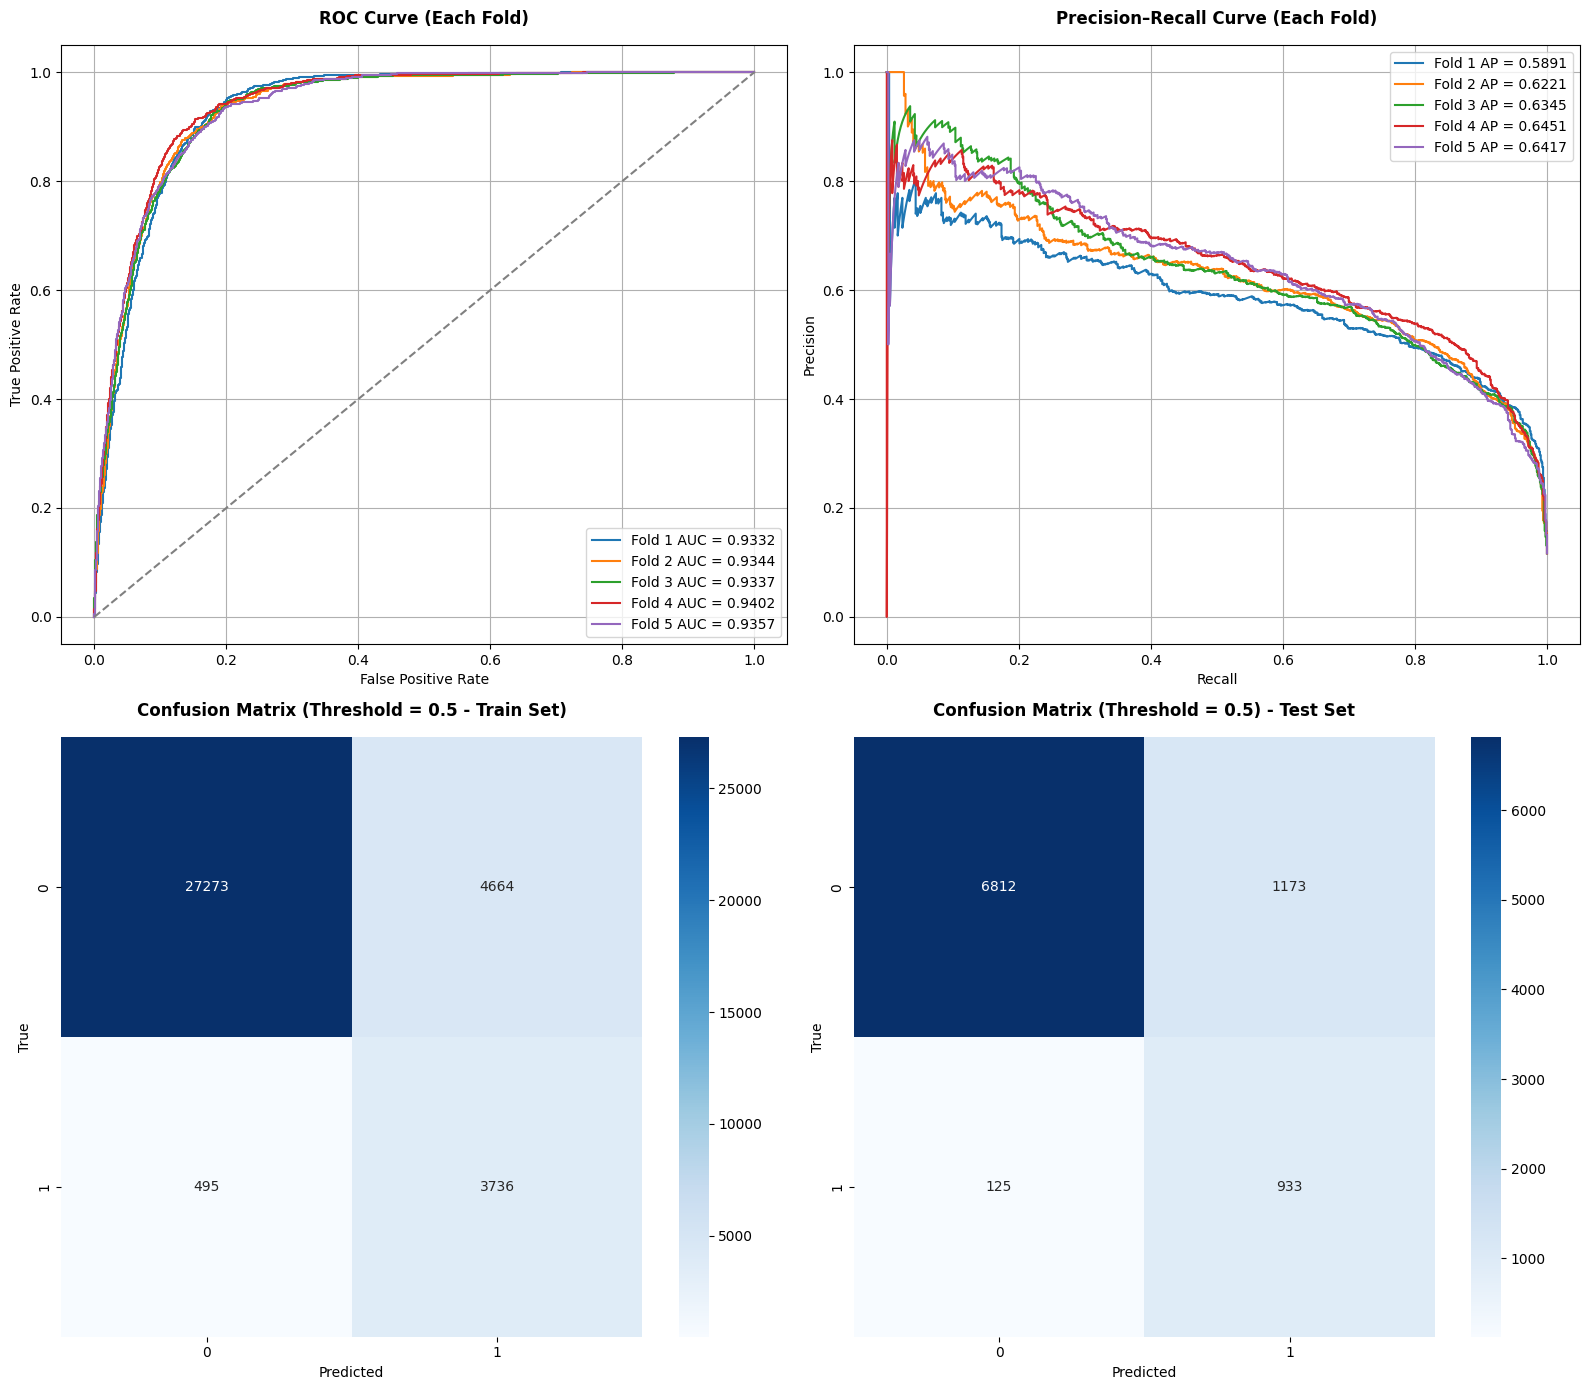

In [30]:
model_hgbc = HistGradientBoostingClassifier(**study_hgbc.best_params, n_iter_no_change=50, validation_fraction=0.1, early_stopping=True,
                                            class_weight="balanced", random_state=random_state)
oof_pred_hgbc, test_pred_hgbc, fold_auc_hgbc, fold_models_hgbc = run_oof(model = model_hgbc, X = X_train_prepared, y = y_train.values, 
                                                                         X_test = X_test_prepared, y_test=y_test, logger=logger)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Evaluation</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Evaluation
    </h1>
</div>

2026-03-09 14:42:08 | INFO     | Starting SHAP comparison across models
2026-03-09 14:42:08 | INFO     | Sampling 1000 rows for SHAP computation
2026-03-09 14:42:08 | INFO     | Computing SHAP values for CatBoostClassifier


PermutationExplainer explainer: 1001it [01:14, 12.82it/s]                         

2026-03-09 14:43:22 | INFO     | 
             feature  importance
2           duration    0.185991
5                day    0.037096
34   contact_unknown    0.036657
43         month_may    0.021095
6           campaign    0.020120
1            balance    0.017115
32  contact_cellular    0.016725
28        housing_no    0.015195
40         month_jul    0.013622
49  poutcome_success    0.012344
29       housing_yes    0.010761
38         month_feb    0.010329
36         month_aug    0.010165
41         month_jun    0.009683
50  poutcome_unknown    0.009512
0                age    0.009446
44         month_nov    0.007895
3              pdays    0.007675
35         month_apr    0.007599
45         month_oct    0.007392
2026-03-09 14:43:22 | INFO     | ********************************************************************************


2026-03-09 14:43:22 | INFO     | Computing SHAP values for LGBMClassifier


PermutationExplainer explainer: 1001it [00:52, 15.32it/s]                          

2026-03-09 14:44:14 | INFO     | 
             feature  importance
2           duration    0.140780
34   contact_unknown    0.051038
28        housing_no    0.027858
49  poutcome_success    0.016909
43         month_may    0.016592
36         month_aug    0.013381
40         month_jul    0.012136
1            balance    0.011917
5                day    0.011341
0                age    0.009081
3              pdays    0.008727
6           campaign    0.008241
41         month_jun    0.007566
32  contact_cellular    0.007197
45         month_oct    0.006300
38         month_feb    0.005402
30           loan_no    0.005170
44         month_nov    0.003902
42         month_mar    0.003757
29       housing_yes    0.003575
2026-03-09 14:44:14 | INFO     | ********************************************************************************


2026-03-09 14:44:14 | INFO     | Computing SHAP values for HistGradientBoostingClassifier


PermutationExplainer explainer: 1001it [03:31,  4.51it/s]                          

2026-03-09 14:47:46 | INFO     | 
               feature  importance
2             duration    0.188130
34     contact_unknown    0.044409
43           month_may    0.041075
5                  day    0.030154
6             campaign    0.021636
28          housing_no    0.021330
40           month_jul    0.018260
1              balance    0.017604
49    poutcome_success    0.014645
36           month_aug    0.012791
0                  age    0.011387
41           month_jun    0.010154
20     marital_married    0.009431
32    contact_cellular    0.008430
3                pdays    0.008337
44           month_nov    0.007115
30             loan_no    0.007046
24  education_tertiary    0.006624
38           month_feb    0.005999
22   education_primary    0.004665
2026-03-09 14:47:46 | INFO     | ********************************************************************************


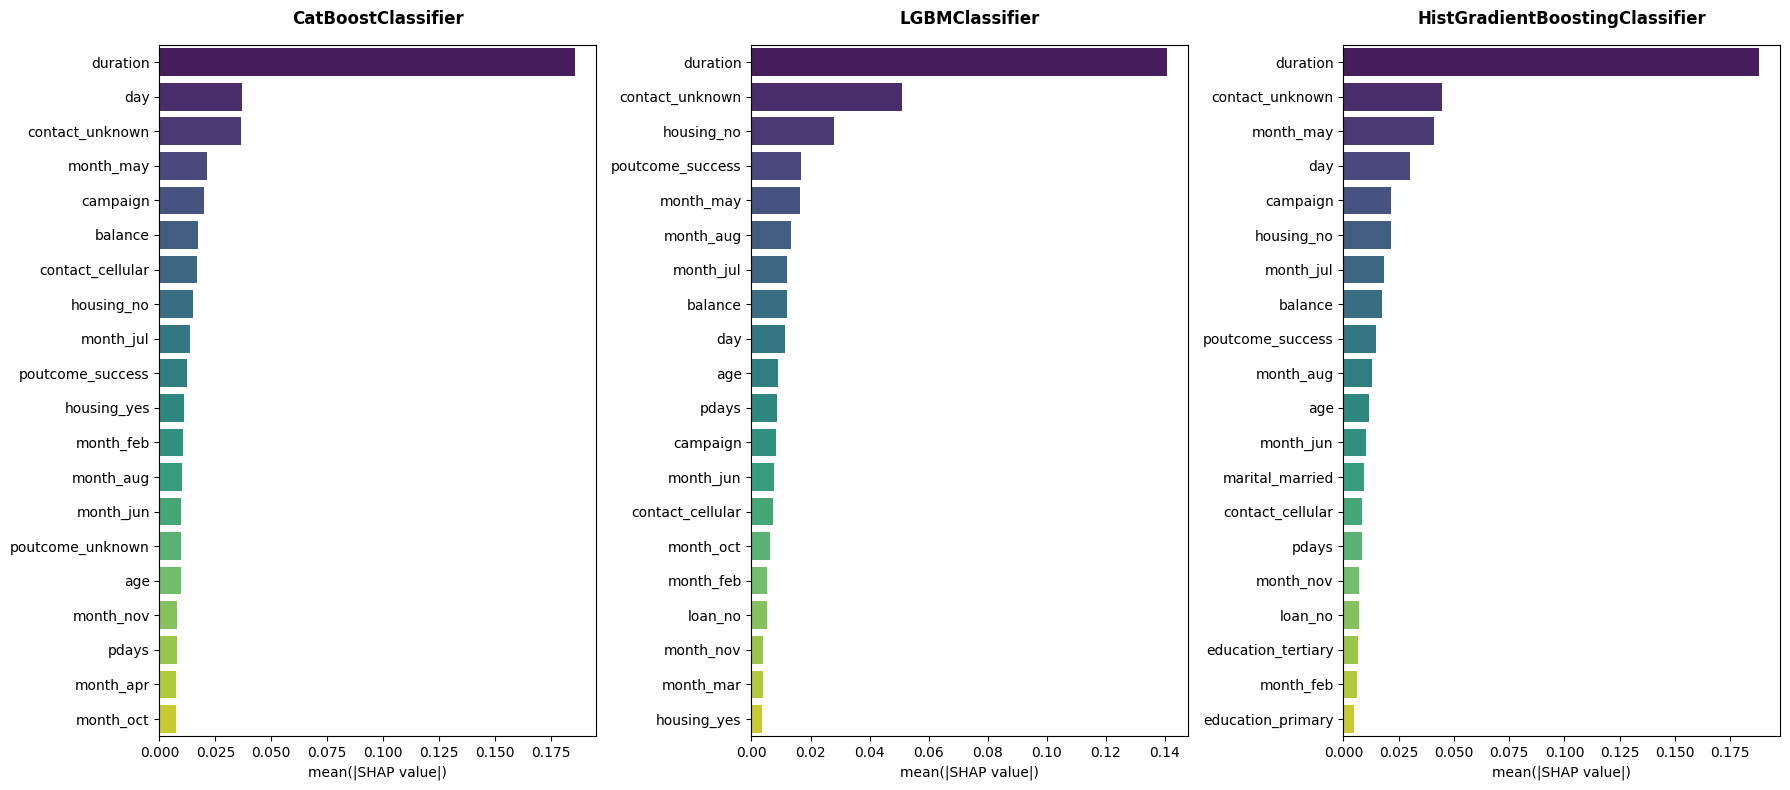

2026-03-09 14:47:46 | INFO     | SHAP comparison completed


In [31]:
max_index_cat = fold_auc_cb.index(max(fold_auc_cb))
max_index_lgbm = fold_auc_lgbm.index(max(fold_auc_lgbm))
max_index_hgbc = fold_auc_hgbc.index(max(fold_auc_hgbc))

list_model = [fold_models_cb[max_index_cat], fold_models_lgbm[max_index_lgbm], fold_models_hgbc[max_index_hgbc]]
shap_compare_models(models=list_model, X_test=X_test_prepared, logger=logger, feature_names=clean_features)

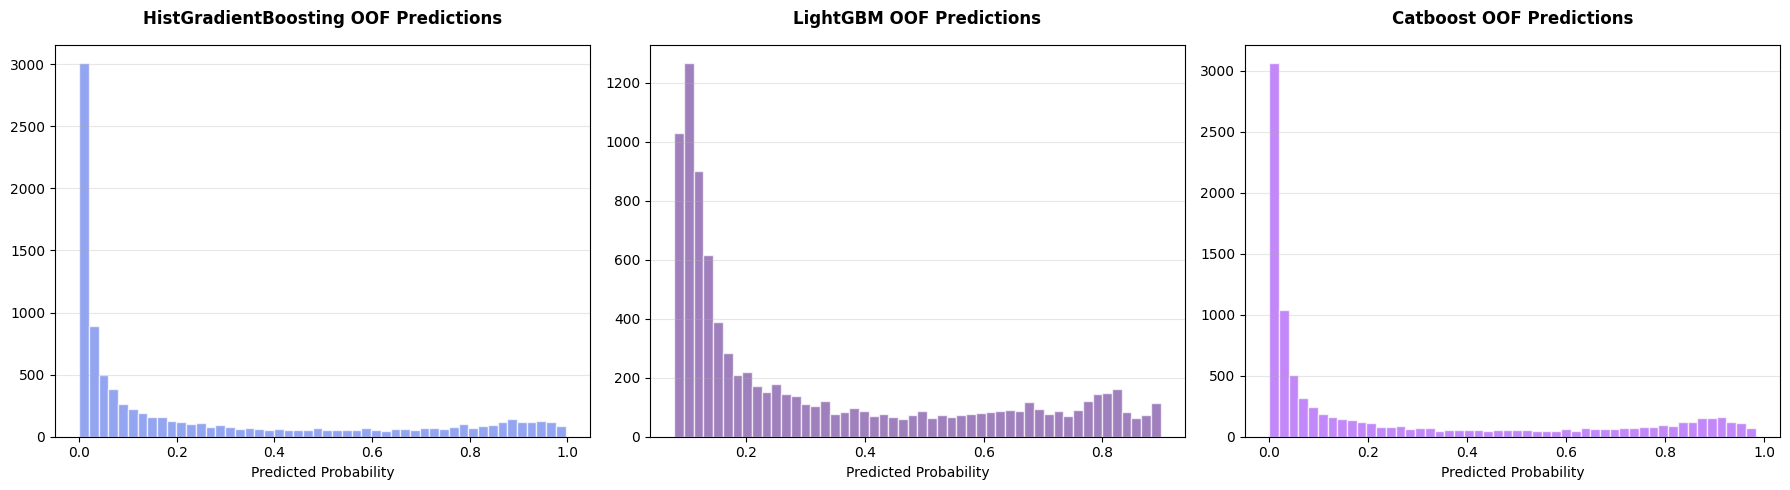

In [32]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
COLORS = ["#667eea", "#764ba2", "#a855f7", "#f093fb", "#fbc2eb"]

ax[0].hist(test_pred_cb, bins=50, color=COLORS[0], alpha=0.7, edgecolor="white")
ax[0].set_title("HistGradientBoosting OOF Predictions", fontsize=12, fontweight="bold", pad=15)
ax[0].set_xlabel("Predicted Probability", fontsize=10)
ax[0].grid(axis="y", alpha=0.3)

ax[1].hist(test_pred_lgbm, bins=50, color=COLORS[1], alpha=0.7, edgecolor="white")
ax[1].set_title("LightGBM OOF Predictions", fontsize=12, fontweight="bold", pad=15)
ax[1].set_xlabel("Predicted Probability", fontsize=10)
ax[1].grid(axis="y", alpha=0.3)

ax[2].hist(test_pred_hgbc, bins=50, color=COLORS[2], alpha=0.7, edgecolor="white")
ax[2].set_title("Catboost OOF Predictions", fontsize=12, fontweight="bold", pad=15)
ax[2].set_xlabel("Predicted Probability", fontsize=10)
ax[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
hgbc_binary = (test_pred_hgbc >= 0.5).astype(int)
lgb_binary = (test_pred_lgbm >= 0.5).astype(int)
cat_binary = (test_pred_cb >= 0.5).astype(int)

logger.info("HistGradientBoosting Classification Report:")
logger.info("\n" + classification_report(y_test, hgbc_binary, target_names=['No', 'Yes']))
logger.info("*" * 80)

logger.info("LightGBM Classification Report:")
logger.info("\n" + classification_report(y_test, lgb_binary, target_names=['No', 'Yes']))
logger.info("*" * 80)

logger.info("CatBoost Classification Report:")
logger.info("\n" + classification_report(y_test, cat_binary, target_names=['No', 'Yes']))
logger.info("*" * 80)

2026-03-09 14:47:47 | INFO     | HistGradientBoosting Classification Report:
2026-03-09 14:47:47 | INFO     | 
              precision    recall  f1-score   support

          No       0.98      0.85      0.91      7985
         Yes       0.44      0.88      0.59      1058

    accuracy                           0.86      9043
   macro avg       0.71      0.87      0.75      9043
weighted avg       0.92      0.86      0.88      9043

2026-03-09 14:47:47 | INFO     | ********************************************************************************
2026-03-09 14:47:47 | INFO     | LightGBM Classification Report:
2026-03-09 14:47:47 | INFO     | 
              precision    recall  f1-score   support

          No       0.98      0.83      0.90      7985
         Yes       0.41      0.88      0.56      1058

    accuracy                           0.84      9043
   macro avg       0.70      0.86      0.73      9043
weighted avg       0.91      0.84      0.86      9043

2026-03-09 14:47:47 | 

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Happy coding 🙌😊
    </p>
</div>
